# petri clash v2: the full walkthrough

this notebook is a complete account of how version 2 of petri clash was designed, built, trained, debugged, and shipped.

it is not documentation. it is closer to a postmortem that the project survived. the goal is to explain the reasoning behind every meaningful decision, show the real training artifacts, and reconstruct the actual sequence of work from branch creation to final merge.

if you read this without running a single cell, you should still walk away understanding:

- what an nca is and why it makes clash possible
- why v2 was necessary after v1 proved the idea
- how the trainer package works and what each loss term does
- what collapsed, what converged, and why seeds matter
- how the clash loop evolved from broken to momentum-based
- what is actually shipped in the weights folder right now

if you do run the cells, they will pull real data from the repo: actual scores, actual previews, actual metrics.

## why v2 exists

v1 worked. two ncas could grow on a shared grid and fight over territory. the shapes were recognizable, the clash was fun to watch, and the whole thing ran in real time on a laptop.

but v1 had a ceiling.

the training loop was simple: mse between predicted rgba and the target, a pool of partial states, damage augmentation, and a fixed rollout range of 64-96 steps. the model was 16 channels, 128 hidden units. training ran for 3000 steps on whatever device you had. no eval, no best checkpoint, no curriculum, no early stopping. you just trained and hoped the result looked decent.

that was fine for proving the concept. it was not fine for:

- long-horizon stability (organisms would dissolve after a few hundred clash steps)
- remote training on a rented gpu (no resume, no metrics, no way to monitor)
- multi-target sweeps (training 9 shapes by hand is tedious and error-prone)
- actual shape fidelity (the loss function was too blunt to produce sharp edges)

v2 was built to fix all of that. it keeps the same nca architecture but wraps it in a real training system: stronger losses, a rollout curriculum, proper eval, checkpointing, tensorboard, collapse detection, convergence stopping, and a seed retry strategy that handles the fact that some random initializations just die.

the split happened in a single commit. v1 went into `v1/`. v2 went into `v2/`. they share no code, no weights, and no targets.

## the repo layout

let's look at what we are working with.

In [1]:
import os
from pathlib import Path

# find the repo root relative to wherever this notebook runs
NOTEBOOK_DIR = Path(os.getcwd())
V2_ROOT = NOTEBOOK_DIR if NOTEBOOK_DIR.name == "v2" else NOTEBOOK_DIR / "v2"
REPO_ROOT = V2_ROOT.parent

print("repo root:", REPO_ROOT)
print()

for item in sorted(REPO_ROOT.iterdir()):
    if item.name.startswith(".") or item.name == "__pycache__":
        continue
    tag = "dir" if item.is_dir() else "file"
    print(f"  {item.name:40s} [{tag}]")

repo root: /home/ilyyeees/repos/petri clash

  README.md                                [file]
  v1                                       [dir]
  v2                                       [dir]


In [2]:
# inside v2/
def tree(root, prefix="", skip_dirs={"__pycache__", ".git", "tensorboard"}):
    entries = sorted(root.iterdir(), key=lambda p: (not p.is_dir(), p.name))
    entries = [e for e in entries if e.name not in skip_dirs and not e.name.endswith(".pyc")]
    for i, entry in enumerate(entries):
        connector = "--- " if i == len(entries) - 1 else "|-- "
        if entry.is_dir() and entry.name in ("previews", "checkpoints"):
            count = len(list(entry.iterdir()))
            print(f"{prefix}{connector}{entry.name}/ ({count} files)")
        elif entry.is_dir():
            print(f"{prefix}{connector}{entry.name}/")
            extension = "|   " if i < len(entries) - 1 else "    "
            tree(entry, prefix=prefix + extension, skip_dirs=skip_dirs)
        else:
            size_kb = entry.stat().st_size / 1024
            print(f"{prefix}{connector}{entry.name} ({size_kb:.0f} KB)")

tree(V2_ROOT)

|-- runs_v2/
|   --- clash_bootstrap/
|-- targets/
|   |-- 01_heart.png (1 KB)
|   |-- 02_star.png (1 KB)
|   |-- 03_sun.png (1 KB)
|   |-- 04_moon.png (1 KB)
|   |-- 05_bolt.png (1 KB)
|   |-- 06_flower.png (1 KB)
|   |-- 07_umbrella.png (1 KB)
|   |-- 08_yin.png (1 KB)
|   --- 09_skull.png (1 KB)
|-- trainer/
|   |-- configs/
|   |   --- single_gpu_base.toml (1 KB)
|   |-- scripts/
|   |   |-- bootstrap_vast.sh (2 KB)
|   |   |-- bundle_group.sh (0 KB)
|   |   |-- launch_remote.sh (1 KB)
|   |   |-- preflight.sh (0 KB)
|   |   |-- run_all.sh (0 KB)
|   |   --- status.sh (0 KB)
|   |-- README.md (3 KB)
|   |-- __init__.py (0 KB)
|   |-- bundle_run.py (2 KB)
|   |-- common.py (6 KB)
|   |-- eval_v2.py (2 KB)
|   |-- preflight.py (2 KB)
|   |-- requirements.txt (0 KB)
|   |-- train_all_v2.py (5 KB)
|   --- train_v2.py (25 KB)
|-- weights/
|   |-- 01_heart/
|   |   |-- seed_000/
|   |   |   |-- checkpoints/ (2 files)
|   |   |   |-- previews/ (24 files)
|   |   |   |-- best_summary.json 

the key things to notice:

- `nca.py` is the model. identical architecture to v1 but configured with more channels.
- `train.py` is the single-target entry point. it wraps the trainer package.
- `clash.py` is the pygame game loop. this is what you actually run.
- `trainer/` is the full training stack: multi-target sweeps, eval, checkpointing, bundling.
- `weights/` holds the shipped artifacts: two targets (heart and star), multiple seeds each.
- `targets/` has nine shapes, but only heart and star have trained weights so far.

## the git story: how this actually happened

this section reconstructs the real order of work. not the order that sounds logical in retrospect, but the actual order that commits landed in.

the project started as a single `main` branch. the first commits built the v1 stack from scratch:

In [3]:
import subprocess

def git(*args):
    result = subprocess.run(
        ["git"] + list(args),
        cwd=str(REPO_ROOT),
        capture_output=True, text=True
    )
    return result.stdout.strip()

# the full history graph
print(git("log", "--all", "--oneline", "--graph", "--decorate"))

* a56ec23 (HEAD -> main, origin/main, origin/HEAD) store full heart and star training artifacts
* 1b68c75 add team color render flag
* 704939a add momentum-based clash control
* 29f20fb add fixed clash spawn positions
* 2ad0b6c fix v2 cwd handling
* 0dc6ca9 use v2 trainer for bootstrap
* 89cb84a rename v2 trainer package
* 4f0979a ignore pulled training artifacts
* 043806b split repo into v1 and v2
| * 9b972b7 (origin/v2-single-gpu-training, v2-single-gpu-training) fix rng restore on resume
| * 299af33 retry seeds only after collapse
| * 95d04bf stop dead runs and use seed zero
| * 3e2f48f teach clash to load v2 seeds
| * 7c0e77a use venv for remote runs
| * cc3a2fd make bootstrap install torch
| * 9309be8 retarget v2 for single gpu
| * 005d579 tighten v2 training flow
| * 78e1303 finish v2 remote training stack
| * bed7772 add v2 orchestration tools
| * f7c290d add v2 training core
|/  
* c26d960 mention walkthrough notebook in readme
* 716ea15 add build walkthrough notebook
* 3d8ed2a

reading the graph from bottom to top, the story is:

### phase 1: v1 on main (commits 54e97fa through 716ea15)

this is the original build. `nca.py` landed first, then `train.py`, then `clash.py`. a conda env was added. the clash loop got stabilized. trained heart and star weights were committed. the v1 walkthrough notebook was written. all of this lived at the repo root with no version folders.

### phase 2: the v2 branch (commits f7c290d through 9b972b7)

at commit `c26d960` (the notebook mention in the readme), a new branch `v2-single-gpu-training` forked off.

this branch was not a gentle refactor. it was a full rewrite of the training system:

- `f7c290d` added the v2 training core: the nca model stayed the same but the trainer got a new loss function, rollout curriculum, eval pipeline, and checkpoint system.
- `bed7772` added orchestration tools: the train-all script, bundle script, preflight.
- `78e1303` finished the remote stack: shell scripts for bootstrapping, launching, monitoring.
- `005d579` tightened the training flow.
- `9309be8` retargeted everything for a single gpu instead of multi-gpu.
- `cc3a2fd` and `7c0e77a` fixed the bootstrap and venv handling for remote machines.
- `3e2f48f` taught clash to load v2-format seed checkpoints.
- `95d04bf` introduced the seed zero strategy and dead-run stopping.
- `299af33` refined when seeds get retried (only after collapse, not on every failure).
- `9b972b7` fixed rng restore on resume so that resumed runs reproduce the same sequence.

### phase 3: the merge and post-merge work (commits 043806b through a56ec23)

back on main, commit `043806b` split the repo into `v1/` and `v2/`. the v2 branch code was brought into `v2/` and then refined:

- the trainer package was renamed (`89cb84a`)
- bootstrap was rewired to use the v2 trainer (`0dc6ca9`)
- cwd handling was fixed so the trainer resolves paths correctly from any working directory (`2ad0b6c`)
- fixed spawn positions were added to clash (`29f20fb`)
- momentum-based clash control replaced the old binary ownership model (`704939a`)
- team color rendering was added (`1b68c75`)
- the full trained heart and star artifacts were committed (`a56ec23`)

In [4]:
# commits with dates to see the actual timeline
print(git("log", "--all", "--format=%h %ai %s"))

a56ec23 2026-03-22 23:29:09 +0100 store full heart and star training artifacts
1b68c75 2026-03-22 23:10:08 +0100 add team color render flag
704939a 2026-03-22 23:02:39 +0100 add momentum-based clash control
29f20fb 2026-03-22 22:48:52 +0100 add fixed clash spawn positions
2ad0b6c 2026-03-22 22:40:45 +0100 fix v2 cwd handling
0dc6ca9 2026-03-22 22:34:06 +0100 use v2 trainer for bootstrap
89cb84a 2026-03-22 22:27:06 +0100 rename v2 trainer package
4f0979a 2026-03-22 22:18:50 +0100 ignore pulled training artifacts
043806b 2026-03-22 22:14:36 +0100 split repo into v1 and v2
9b972b7 2026-03-22 22:00:15 +0100 fix rng restore on resume
299af33 2026-03-22 21:55:12 +0100 retry seeds only after collapse
95d04bf 2026-03-22 21:47:56 +0100 stop dead runs and use seed zero
3e2f48f 2026-03-22 21:41:59 +0100 teach clash to load v2 seeds
7c0e77a 2026-03-22 19:20:36 +0100 use venv for remote runs
cc3a2fd 2026-03-22 19:18:58 +0100 make bootstrap install torch
9309be8 2026-03-22 19:05:44 +0100 retarget v2

one thing that stands out: all of this happened in a single day. the v1 build, the v2 branch, the merge, the post-merge fixes, and the final artifact commit. it was a dense day.

## the nca model

the neural cellular automaton is the core of everything. the same architecture powers both v1 and v2. let's look at it.

In [5]:
import sys
sys.path.insert(0, str(V2_ROOT))

import torch
from nca import NCA, make_seed

# v1 defaults vs v2 defaults
v1_model = NCA(channels=16, hidden_size=128, fire_rate=0.5)
v2_model = NCA(channels=24, hidden_size=256, fire_rate=0.5)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

print(f"v1 model: {count_params(v1_model):,} parameters")
print(f"  channels=16, hidden_size=128")
print(f"  perception filter shape: {tuple(v1_model.perception_filters.shape)}")
print(f"  fc0: {tuple(v1_model.fc0.weight.shape)}")
print(f"  fc1: {tuple(v1_model.fc1.weight.shape)}")
print()
print(f"v2 model: {count_params(v2_model):,} parameters")
print(f"  channels=24, hidden_size=256")
print(f"  perception filter shape: {tuple(v2_model.perception_filters.shape)}")
print(f"  fc0: {tuple(v2_model.fc0.weight.shape)}")
print(f"  fc1: {tuple(v2_model.fc1.weight.shape)}")

v1 model: 8,336 parameters
  channels=16, hidden_size=128
  perception filter shape: (48, 1, 3, 3)
  fc0: (128, 48, 1, 1)
  fc1: (16, 128, 1, 1)

v2 model: 24,856 parameters
  channels=24, hidden_size=256
  perception filter shape: (72, 1, 3, 3)
  fc0: (256, 72, 1, 1)
  fc1: (24, 256, 1, 1)


the architecture is the same in both versions. the only change is the size:

- v1 uses 16 channels (4 rgba + 12 hidden) and 128 hidden units in the update mlp.
- v2 uses 24 channels (4 rgba + 20 hidden) and 256 hidden units.

the model works in three stages per step:

1. **perceive**: each channel gets convolved with three fixed 3x3 filters (identity, sobel-x, sobel-y). this gives each cell a view of its own value plus gradients in both directions. the perception is grouped, so channel k only sees itself and its neighbors. no cross-channel perception at this stage. the output is 3x the channel count.

2. **update**: the perceived features go through a two-layer 1x1 convolution (which is really a per-pixel mlp). relu between the layers. the output is a delta, not an absolute state. this is critical: the model learns *how much to change*, not *what to be*.

3. **stochastic firing**: with probability `fire_rate` (0.5 by default), each cell applies its update. the rest stay frozen for that step. this forces the model to learn rules that work asynchronously. if every cell updated in lockstep, the model could cheat by relying on global synchronization.

4. **alive masking**: before and after the update, the model checks whether the alpha channel in a 3x3 neighborhood exceeds 0.1. cells that have no alive neighbor before or after the step get zeroed out. this prevents dead regions from spontaneously generating noise.

### why the last layer starts at zero

the `fc1` layer (the output layer) is explicitly initialized to zero weights and zero bias. this means the very first forward pass produces zero deltas everywhere. the seed starts with one pixel of alpha and one pixel of hidden channel 4, and the first few steps produce zero changes.

this is not a bug. it ensures that untrained models do not produce chaotic initial rollouts. without this, the first training steps would be fighting against random noise from the initialization, and the pool would fill with garbage before the model had any chance to learn.

### why sobel instead of learned filters

the perception filters are fixed, not learned. this sounds limiting but it is actually freeing: it means the model always has access to the local gradient structure, regardless of how training goes. the identity filter gives "what am i", the sobel filters give "what is changing around me". that is enough information for the mlp to learn any local update rule.

learned perception filters would make the model more expressive but also more fragile. and since this is a 1x1 convolution into a 256-wide hidden layer immediately after, the mlp has plenty of capacity to combine the fixed features however it needs to.

### the seed

every organism starts from a single pixel. this is the seed.

In [6]:
seed = make_seed(1, channels=24, height=48, width=48, device="cpu")
print(f"seed shape: {tuple(seed.shape)}")
print(f"total nonzero values: {int((seed != 0).sum())}")
print(f"alpha channel sum: {float(seed[:, 3].sum()):.1f}")
print(f"hidden channel 4 sum: {float(seed[:, 4].sum()):.1f}")
print(f"everything else: {float(seed[:, :3].sum() + seed[:, 5:].sum()):.1f}")
print()
print("the seed is one pixel of alpha=1.0 at the center,")
print("plus one pixel of hidden channel 4 = 1.0 at the same spot.")
print("that is enough signal for the alive mask to keep the cell alive")
print("and for the mlp to start producing nonzero deltas.")

seed shape: (1, 24, 48, 48)
total nonzero values: 2
alpha channel sum: 1.0
hidden channel 4 sum: 1.0
everything else: 0.0

the seed is one pixel of alpha=1.0 at the center,
plus one pixel of hidden channel 4 = 1.0 at the same spot.
that is enough signal for the alive mask to keep the cell alive
and for the mlp to start producing nonzero deltas.


the seed function also supports custom x,y positions. this is used in clash to place two organisms at different spots on the grid, and was later extended to support fixed spawn positions.

## the v2 config

the entire training behavior is controlled by a single toml file. let's look at it.

In [7]:
config_path = V2_ROOT / "trainer" / "configs" / "single_gpu_base.toml"
print(config_path.read_text())

[run]
group_name = "single_gpu_all_targets"
output_root = "runs_v2"
target_glob = "targets/*.png"
seeds = [0]
fallback_seeds = [1, 2]

[runtime]
device = "auto"
matmul_precision = "high"
allow_tf32 = true
benchmark = true

[model]
channels = 24
hidden_size = 256
fire_rate = 0.5

[data]
grid_size = 48
target_size = 40

[train]
steps = 12000
pool_size = 2048
batch_size = 48
lr = 0.0015
weight_decay = 0.0
grad_clip = 1.0
save_every = 250
eval_every = 500
preview_every = 500
fresh_seed_count = 2
damage_prob = 0.6
damage_min_radius_frac = 0.10
damage_max_radius_frac = 0.22
start_rollout_min = 48
start_rollout_max = 96
end_rollout_min = 160
end_rollout_max = 256
channels_last = true
amp = true
amp_dtype = "bfloat16"
compile = true
compile_mode = "default"
resume = true
lr_schedule = "cosine"
warmup_steps = 250
min_lr_scale = 0.08

[loss]
rgba_weight = 0.5
rgb_weight = 1.5
alpha_weight = 1.0
bg_alpha_weight = 2.5
overflow_weight = 5.0
mass_weight = 0.5
hidden_weight = 0.0002
overflow_kernel =

this is the whole config. let me walk through every section.

### [run]

- `seeds = [0]` and `fallback_seeds = [1, 2]`: the trainer tries seed 0 first. if it collapses, it moves to seed 1, then seed 2. this is the seed retry strategy. more on this later.
- `target_glob = "targets/*.png"`: trains all nine shapes.
- `output_root = "runs_v2"`: training artifacts land in `runs_v2/` (not in `weights/`; weights are exported separately).

### [model]

- `channels = 24`: 4 rgba + 20 hidden. v1 used 16. the extra capacity helps with longer rollouts.
- `hidden_size = 256`: the update mlp is wider. v1 used 128.
- `fire_rate = 0.5`: same as v1. half the cells update each step.

### [data]

- `grid_size = 48`, `target_size = 40`: same as v1. the target is 40x40 centered on a 48x48 canvas. the 4-pixel border gives the organism room to breathe without clipping against the edge.

### [train]

- `steps = 12000`: v1 used 3000. four times longer.
- `pool_size = 2048`: v1 used 1024. bigger pool means more diversity in the partial states the model trains on.
- `batch_size = 48`: v1 used 8. much bigger batches because we have a gpu now.
- `lr = 0.0015` with `weight_decay = 0.0`: adamw optimizer. slightly lower lr than v1's 2e-3.
- `grad_clip = 1.0`: prevents gradient explosions during long rollouts.
- `fresh_seed_count = 2`: two slots in each batch are always fresh seeds. v1 used 1. this is important: it ensures the model never forgets how to bootstrap from nothing.
- `damage_prob = 0.6`: 60% of pool samples get a random crater before training. v1 used 0.5. higher damage probability teaches resilience.
- `damage_min_radius_frac = 0.10`, `damage_max_radius_frac = 0.22`: craters range from 10% to 22% of the grid size.

### the rollout curriculum

this is one of the most important differences from v1.

- `start_rollout_min = 48`, `start_rollout_max = 96`: at the beginning of training, each batch rolls forward 48-96 steps.
- `end_rollout_min = 160`, `end_rollout_max = 256`: by the end of training, each batch rolls forward 160-256 steps.

the rollout length is linearly interpolated based on training progress. early in training, the model sees short horizons and learns basic growth. late in training, it sees long horizons and must maintain its shape over many steps.

v1 used a fixed range of 64-96 for the entire run. that is why v1 organisms tended to dissolve in clash: they had never been asked to survive beyond 96 steps.

### [loss]

v1 had a single loss: mse between predicted rgba and target rgba. that was it.

v2 has seven loss terms. let's go through them.

## the loss function

the loss in v2 is a weighted sum of seven terms:

### 1. rgba loss (weight 0.5)
plain mse between predicted rgba and target rgba across the whole grid. this is the baseline "does it look right" term. it is downweighted compared to v1 because the other terms handle specifics.

### 2. rgb loss (weight 1.5)
mse between predicted and target rgb, but only on foreground pixels (where the target alpha > 0.01). this is heavily weighted because it is the "does the actual shape have the right colors" term. the foreground masking prevents the model from being rewarded for painting nothing in the background.

### 3. alpha loss (weight 1.0)
mse between predicted and target alpha across the whole grid. this covers both "the shape should be opaque where the target is" and "the background should be transparent."

### 4. bg_alpha loss (weight 2.5)
the squared alpha in background regions (where the target alpha is zero). this is a penalty for the model producing any alpha where there should be nothing. heavily weighted because alpha leaking into the background was one of the main visual artifacts in v1.

### 5. overflow_alpha loss (weight 5.0)
the squared alpha in overflow regions. overflow is defined using a dilated version of the target: a 9x9 max-pool of the target alpha creates a support mask, and overflow is everything outside that support. this is the heaviest weight in the whole loss. it exists because ncas tend to grow tendrils and fringes beyond the target boundary. the overflow penalty crushes that behavior.

### 6. mass loss (weight 0.5)
the squared difference between the mean predicted alpha and the mean target alpha. this is a soft constraint on total opacity: the organism should have roughly the same amount of "stuff" as the target. it prevents both over-growth and under-growth.

### 7. hidden loss (weight 0.0002)
the mean squared value of the hidden channels (channels 4 and above). this is a very light regularizer that discourages the hidden state from growing without bound. the weight is tiny because you do want the hidden channels to be expressive, you just don't want them to explode.

In [8]:
# let's look at the actual loss weights side by side
import json

resolved_path = V2_ROOT / "weights" / "01_heart" / "seed_000" / "resolved_config.json"
config = json.loads(resolved_path.read_text())

print("loss weights used for the actual heart training run:")
print()
for key, value in sorted(config["loss"].items()):
    print(f"  {key:25s} = {value}")

print()
print("for comparison, v1 effectively used:")
print("  mse(pred[:4], target[:4]).mean()")
print("  which is roughly: rgba_weight=1.0 and everything else=0.0")

loss weights used for the actual heart training run:

  alpha_weight              = 1.0
  bg_alpha_weight           = 2.5
  hidden_weight             = 0.0002
  mass_weight               = 0.5
  overflow_kernel           = 9
  overflow_weight           = 5.0
  rgb_weight                = 1.5
  rgba_weight               = 0.5

for comparison, v1 effectively used:
  mse(pred[:4], target[:4]).mean()
  which is roughly: rgba_weight=1.0 and everything else=0.0


the overflow penalty being 5.0 while rgba is only 0.5 tells the story: keeping the organism inside its boundary is ten times more important than matching the exact pixel values. this is a deliberate trade-off. in clash, a model that produces a clean, bounded shape will always look better than one that is technically closer to the target rgb values but leaks alpha everywhere.

## the rollout curriculum in detail

let's visualize how the rollout range changes during training.

In [9]:
train_cfg = config["train"]
total_steps = train_cfg["steps"]

print(f"total training steps: {total_steps}")
print()
print(f"{'step':>8s}  {'progress':>8s}  {'min_rollout':>11s}  {'max_rollout':>11s}")
print("-" * 45)

for step in [1, 1000, 2000, 4000, 6000, 8000, 10000, 12000]:
    progress = (step - 1) / max(total_steps - 1, 1)
    cur_min = int(round(train_cfg["start_rollout_min"] + (train_cfg["end_rollout_min"] - train_cfg["start_rollout_min"]) * progress))
    cur_max = int(round(train_cfg["start_rollout_max"] + (train_cfg["end_rollout_max"] - train_cfg["start_rollout_max"]) * progress))
    cur_max = max(cur_min, cur_max)
    print(f"{step:8d}  {progress:8.2f}  {cur_min:11d}  {cur_max:11d}")

print()
print("by the end of training, the model must survive 160-256 steps")
print("from a pooled partial state (often damaged). that is why")
print("v2 organisms are much more stable in clash than v1 organisms.")

total training steps: 12000

    step  progress  min_rollout  max_rollout
---------------------------------------------
       1      0.00           48           96
    1000      0.08           57          109
    2000      0.17           67          123
    4000      0.33           85          149
    6000      0.50          104          176
    8000      0.67          123          203
   10000      0.83          141          229
   12000      1.00          160          256

by the end of training, the model must survive 160-256 steps
from a pooled partial state (often damaged). that is why
v2 organisms are much more stable in clash than v1 organisms.


## damage training

60% of the time, a pool sample gets a random circular crater before it enters the training batch. this teaches the organism to repair itself.

the damage is applied to all batch slots except the first `fresh_seed_count` slots (which are always clean seeds). the crater radius varies between 10% and 22% of the grid size, which for a 48x48 grid means roughly 5 to 11 pixels.

the damage function is vectorized across the batch using a pre-computed coordinate grid, so it does not loop over samples individually. this was an optimization from the v2 rewrite; v1's damage function used a python for-loop.

damage training is essential for clash because the clash loop itself acts like continuous damage: when territory is lost, the organism's state gets zeroed out in that region. without damage training, organisms would freeze and die the moment they lost any cells.

## the eval pipeline

v1 had no eval at all. the training loss was the only signal. v2 has a proper evaluation that runs every 500 steps.

eval works like this:

1. grow the organism from a single seed for up to 256 steps
2. measure the loss at steps 64, 128, 192, and 256
3. at step 96, blow a hole in the organism (16% radius crater in the center)
4. let it recover for 96 more steps
5. measure the recovery loss
6. combine the tail losses and recovery loss into a single score

the score formula is:

```
score = mean(last 2 rollout losses) * 0.65 + recovery_loss * 0.35
```

recovery gets 35% of the score. this means a model that looks perfect but cannot heal from damage will still get a mediocre score. in the context of clash, self-repair ability is just as important as shape fidelity.

### best vs latest checkpoint

every eval that beats the previous best score saves a `best.pt` checkpoint and a `best_summary.json`. the latest checkpoint (`latest.pt`) is saved every 250 steps regardless and includes the full optimizer state, scaler state, pool, and rng state for resuming.

the best checkpoint is what gets exported to `weights/` and used in clash. the latest checkpoint exists purely for resume support.

## let's look at the actual training results

the repo ships trained weights for two targets: heart and star. each has two seeds. let's see what actually happened.

In [10]:
weights_root = V2_ROOT / "weights"

for target_dir in sorted(weights_root.iterdir()):
    if not target_dir.is_dir():
        continue
    print(f"\n=== {target_dir.name} ===")
    for seed_dir in sorted(target_dir.glob("seed_*")):
        summary_path = seed_dir / "best_summary.json"
        if not summary_path.exists():
            print(f"  {seed_dir.name}: no summary")
            continue
        summary = json.loads(summary_path.read_text())
        score = summary["score"]
        step = summary["step"]

        # check for stop reason in metrics
        metrics_path = seed_dir / "metrics.jsonl"
        stop_reason = "ran to completion"
        if metrics_path.exists():
            for line in metrics_path.open():
                blob = json.loads(line)
                if blob.get("kind") == "run_stop":
                    stop_reason = f"stopped: {blob['reason']} at step {blob['step']}"

        status = "COLLAPSED" if score > 0.1 else "converged"
        print(f"  {seed_dir.name}: score={score:.6f} best_step={step} [{status}] ({stop_reason})")


=== 01_heart ===
  seed_000: score=0.000054 best_step=11000 [converged] (ran to completion)
  seed_001: score=0.674114 best_step=500 [COLLAPSED] (ran to completion)

=== 02_star ===
  seed_000: score=0.884647 best_step=500 [COLLAPSED] (stopped: collapsed at step 3000)
  seed_001: score=0.000046 best_step=7500 [converged] (stopped: converged at step 10000)


### what this tells us

**heart seed 0**: score 0.0000543 at step 11000. this is excellent. the organism converged to near-perfect shape fidelity and recovery. it ran all 12000 steps without early stopping.

**heart seed 1**: score 0.674. this is a complete collapse. the score never dropped below the initial random level. if you look at the metrics, the loss is identical at every eval from step 500 through step 8000+. the hidden channels went to exactly 0.0. the organism died and stayed dead.

**star seed 0**: score 0.885. also collapsed. stopped by the collapse detector at step 3000 after the score had not improved since step 500.

**star seed 1**: score 0.0000461 at step 7500. excellent convergence. the early stopping kicked in at step 10000 because the score had not improved enough since step 7500 (converged patience).

so for both targets: one seed collapsed and one seed converged. this is exactly why the seed retry strategy exists.

## collapse detection and convergence stopping

two separate early stopping mechanisms exist in the trainer:

### collapse detection

a run is considered collapsed when:
- at least 3000 steps have passed
- the best score is worse than 0.2
- the score has not improved by more than 0.001 in the last 1000 steps

this catches runs where the model has effectively died. the hidden channels go to zero, the loss plateaus at the initial level, and nothing is being learned. continuing to train a collapsed run is pure waste.

### convergence stopping

a run is considered converged when:
- at least 10000 steps have passed
- the best score is better than 0.00006
- the score has not improved by more than 0.000005 in the last 500 steps

this catches runs that have reached diminishing returns. the model is already excellent and further training will not meaningfully improve it.

In [11]:
print("stop config:")
for key, value in sorted(config["stop"].items()):
    print(f"  {key:30s} = {value}")

stop config:
  collapsed_min_delta            = 0.001
  collapsed_min_step             = 3000
  collapsed_patience_steps       = 1000
  collapsed_score                = 0.2
  converged_min_delta            = 5e-06
  converged_min_step             = 10000
  converged_patience_steps       = 500
  converged_score                = 6e-05
  enabled                        = True


## the seed strategy evolution

this was one of the more interesting engineering problems in v2.

the original plan was simple: train each target with seed 0. if it works, great.

the problem is that nca training is sensitive to the random initialization. the same architecture, the same config, the same target, but a different random seed can produce either a beautiful organism or a flat dead grid. this is not unique to ncas; it happens with many small models that learn dynamic systems.

the first attempt (`95d04bf` - "stop dead runs and use seed zero") was aggressive: always start with seed 0, and if anything goes wrong, stop. this was too restrictive. it meant that if seed 0 happened to be bad for a particular target, you got nothing.

the refinement (`299af33` - "retry seeds only after collapse") was smarter: try seed 0 first. if it *collapses* (not just fails to converge fast enough), move to seed 1. if seed 1 also collapses, try seed 2. but if a seed is merely slow, let it finish.

the config expresses this as:

```toml
seeds = [0]
fallback_seeds = [1, 2]
```

the `train_all_v2.py` script iterates through the seed order and only advances to the next seed when the current one collapses. this is why we have both collapsed and converged seeds in the shipped weights: the trainer tried seed 0 first, and when it collapsed (for star), it tried seed 1.

## the training previews

every 500 steps, the eval pipeline produces a contact sheet showing:
- the target image
- the organism at several rollout milestones (32, 64, 128, 192, 256 steps)
- the organism after damage + recovery (0, 24, 48, 72, 96 steps of recovery)

these are incredibly useful for understanding what the model learned. let's look at the progression for heart seed 0.


--- step 00500 ---


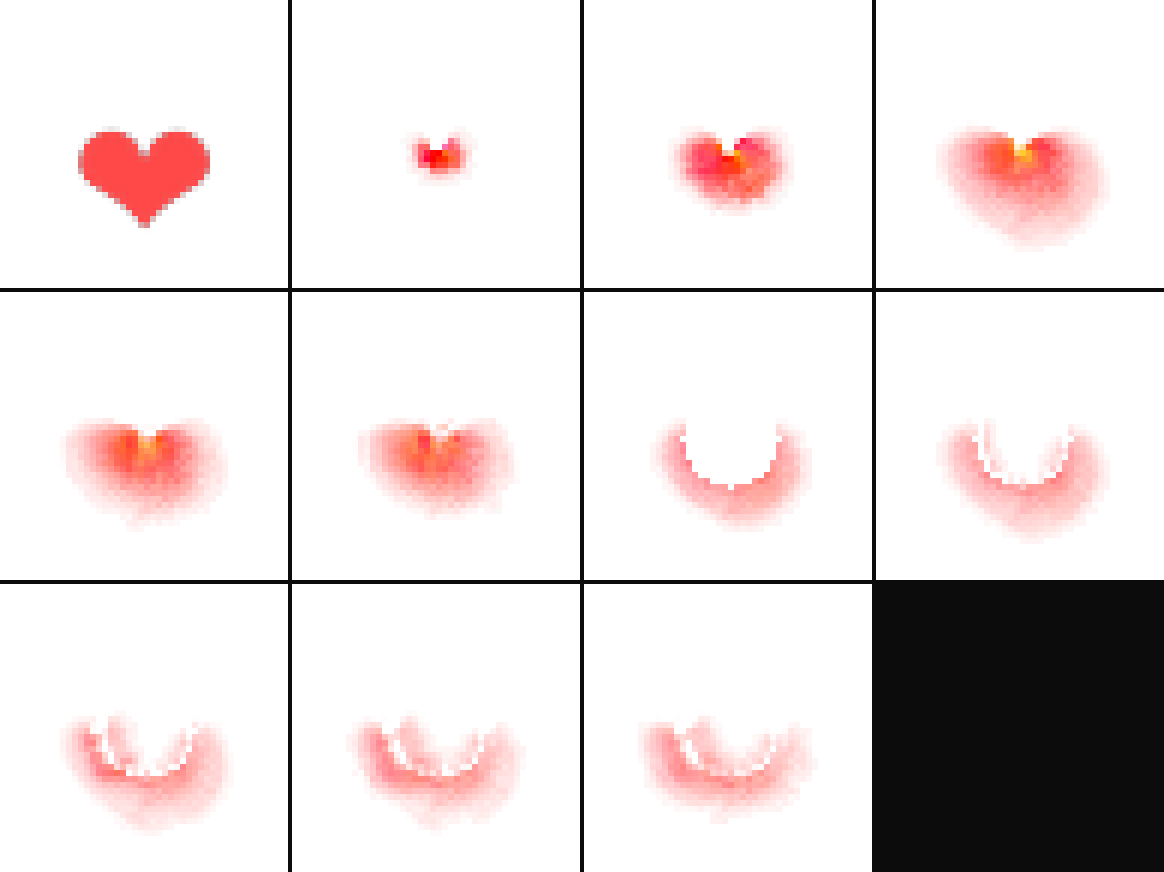


--- step 02000 ---


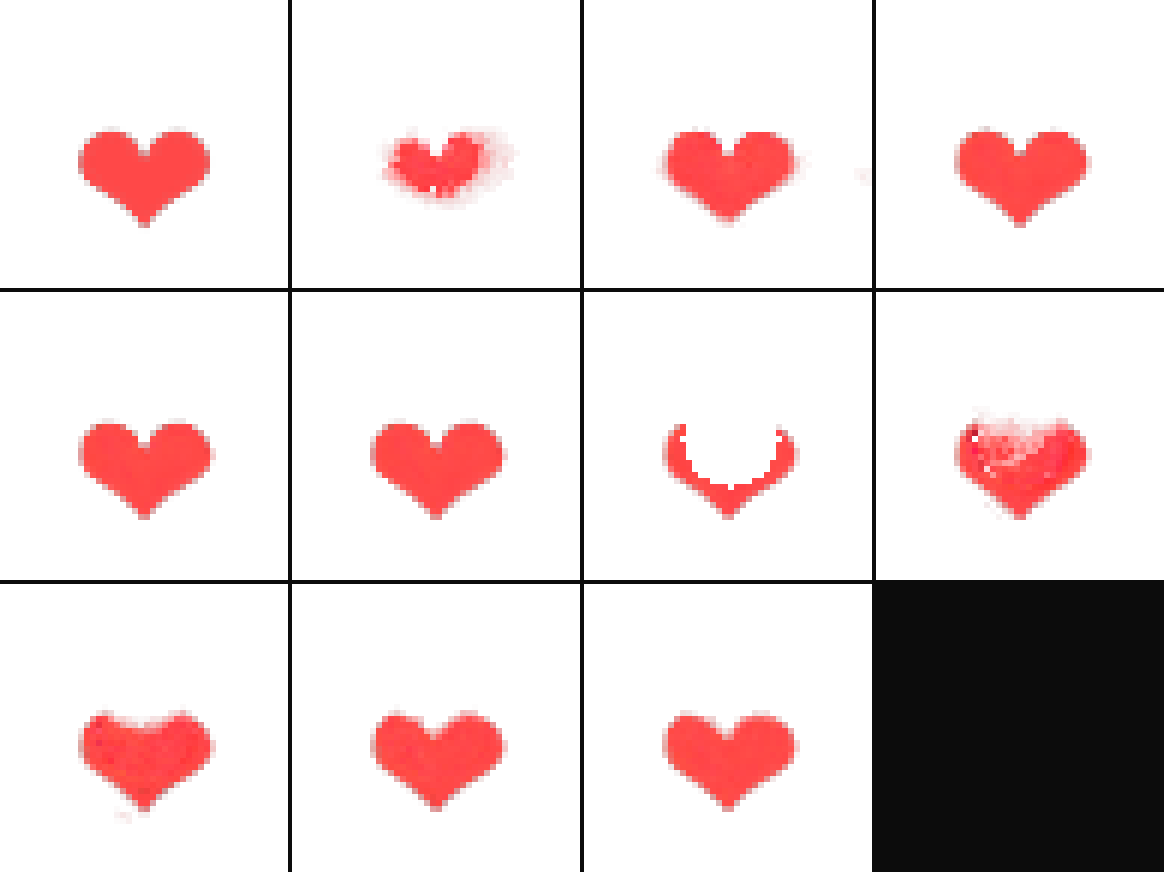


--- step 04000 ---


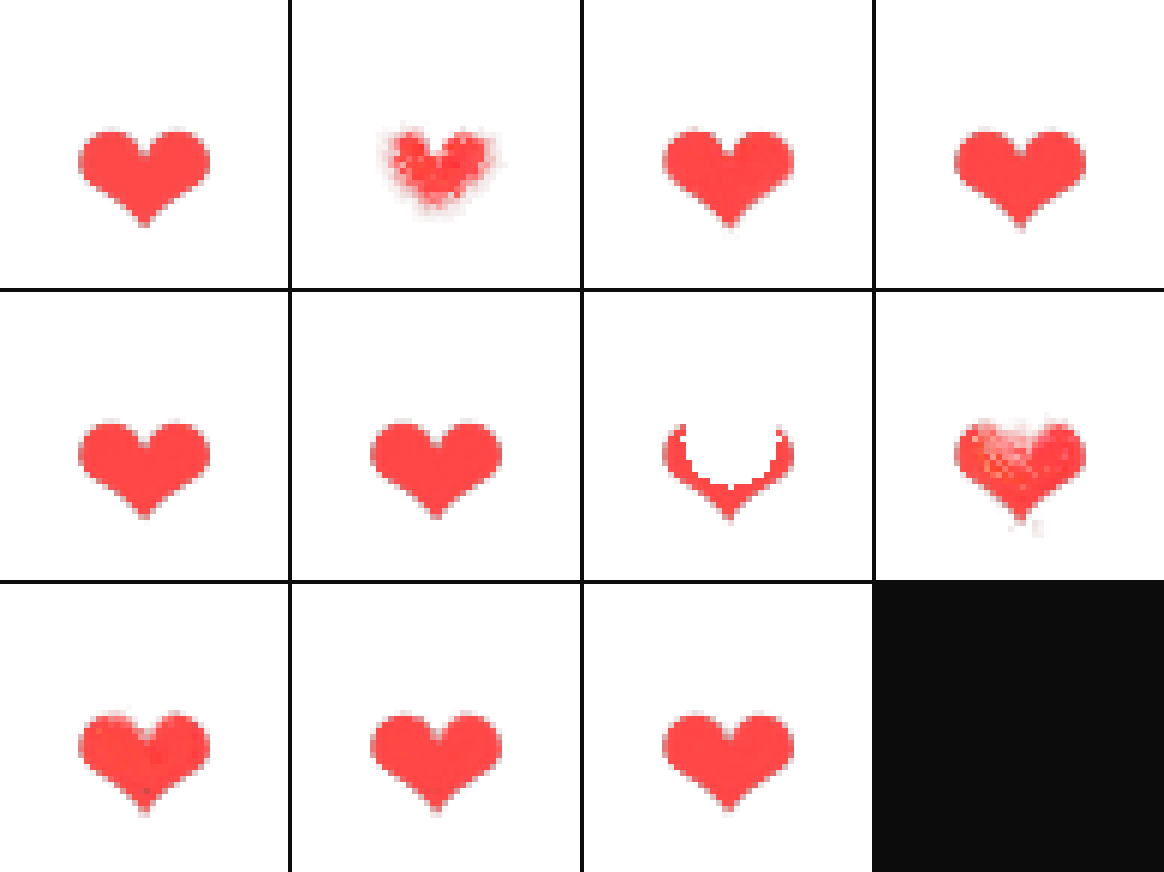


--- step 06000 ---


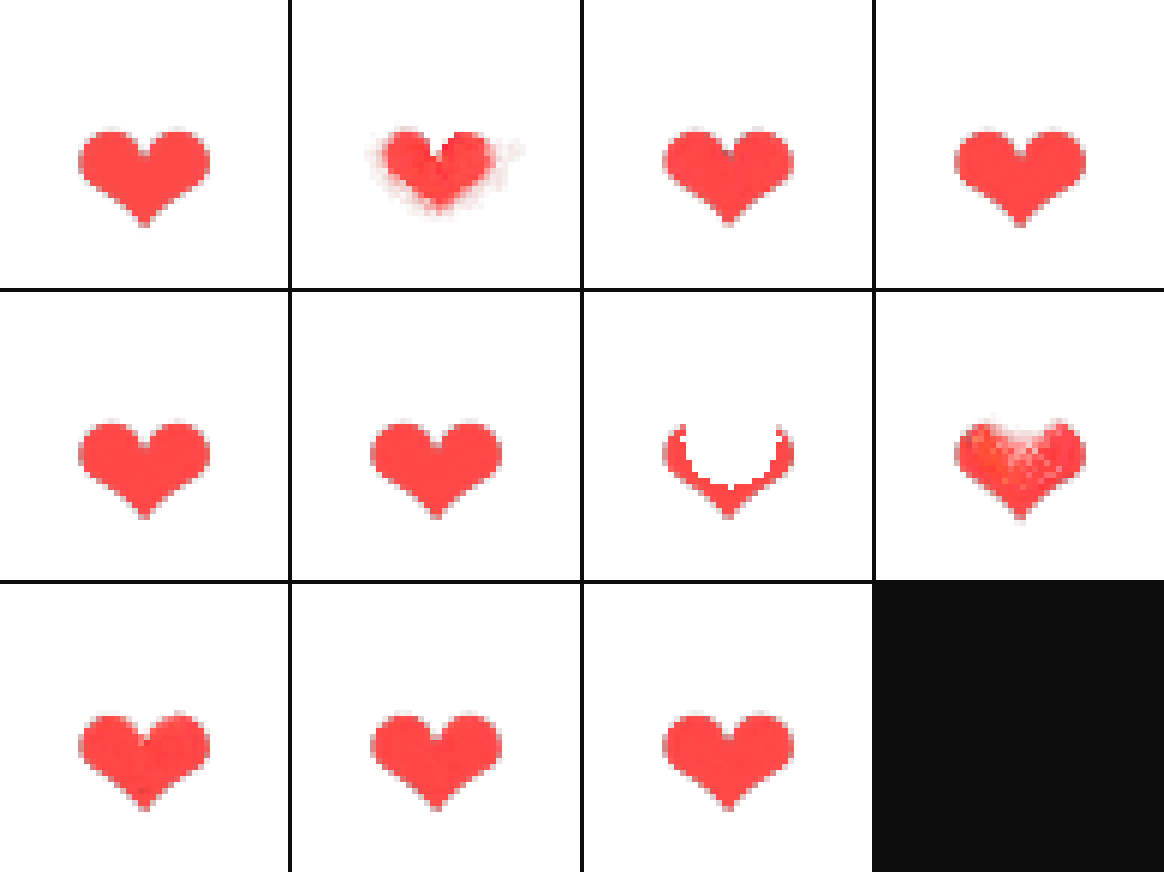


--- step 12000 ---


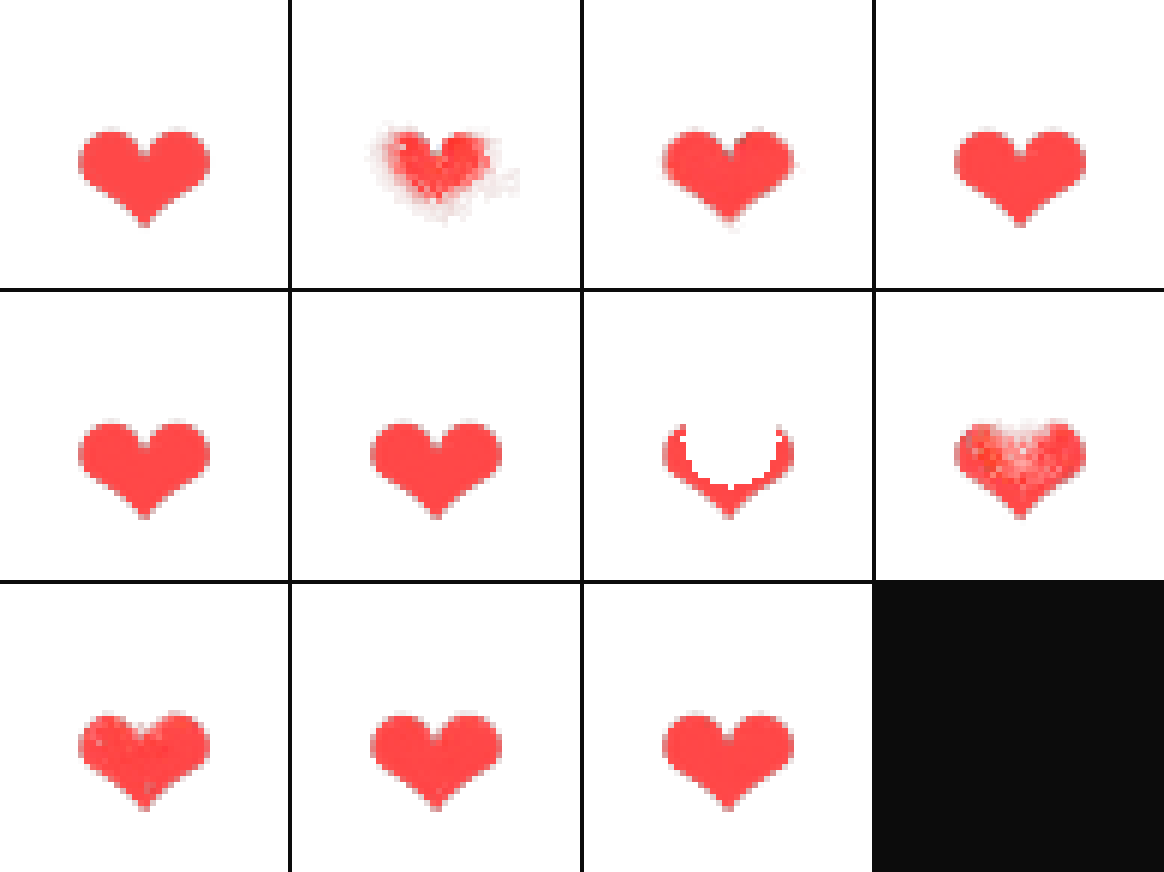

In [12]:
from IPython.display import display, Image as IPImage

heart_previews = sorted((V2_ROOT / "weights" / "01_heart" / "seed_000" / "previews").glob("*_eval.png"))

# show a selection: early, mid, late
milestones = [0, 3, 7, 11, len(heart_previews) - 1]  # roughly steps 500, 2000, 4000, 6000, 12000
for idx in milestones:
    if idx < len(heart_previews):
        path = heart_previews[idx]
        step_num = path.stem.split("_")[1]
        print(f"\n--- step {step_num} ---")
        display(IPImage(filename=str(path)))

you can see the progression clearly:

- early steps: the organism is barely visible, a faint blob that does not really look like anything
- mid steps: the shape is recognizable but the edges are fuzzy and there is alpha leakage
- late steps: the shape is clean, crisp, and survives damage recovery

the contact sheets have the target in the top-left, followed by rollout snapshots, then recovery snapshots. the recovery row starts with the damaged state (crater visible) and shows healing.

standalone eval image for the final heart checkpoint:


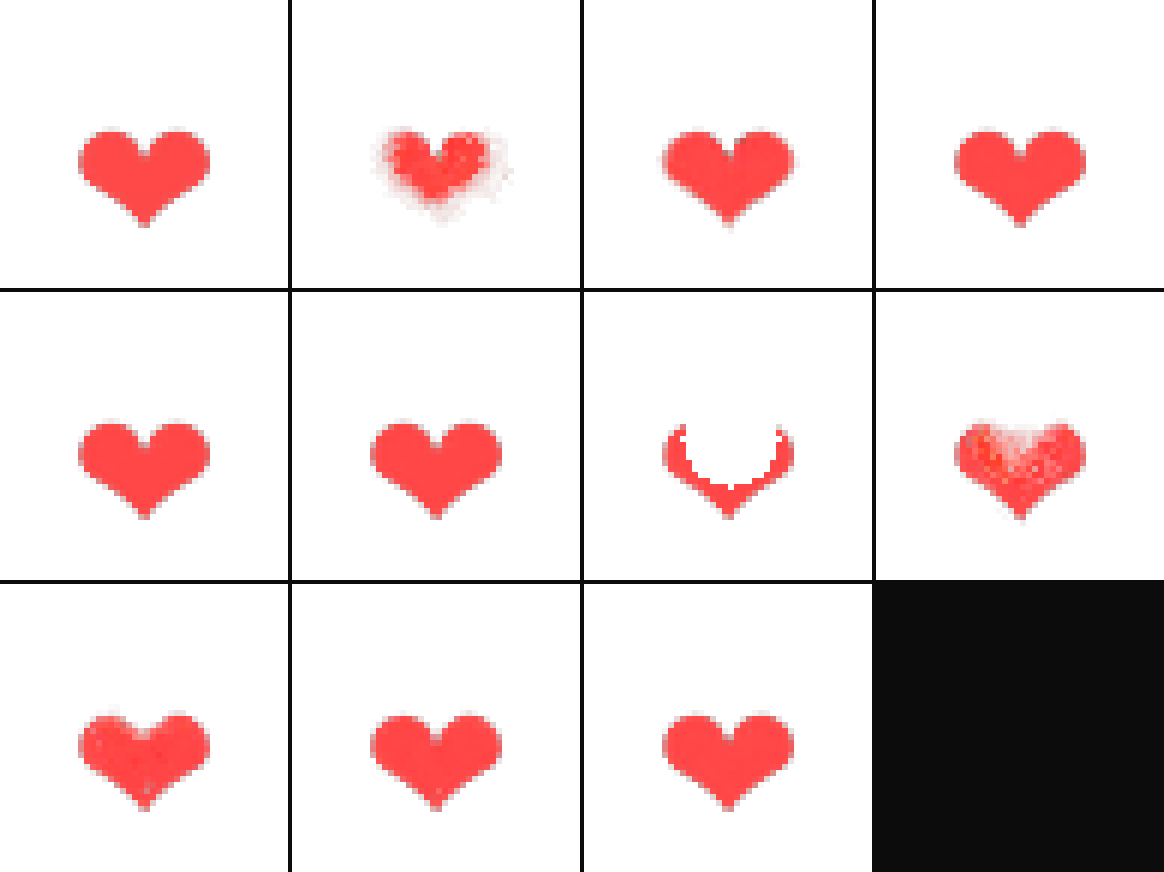

In [13]:
# also show the heart_eval.png if it exists (standalone eval image)
heart_eval_path = V2_ROOT / "weights" / "01_heart" / "seed_000" / "heart_eval.png"
if heart_eval_path.exists():
    print("standalone eval image for the final heart checkpoint:")
    display(IPImage(filename=str(heart_eval_path)))

### star previews

let's look at the star as well. remember, star seed 0 collapsed, so we are looking at seed 1.


--- step 00500 ---


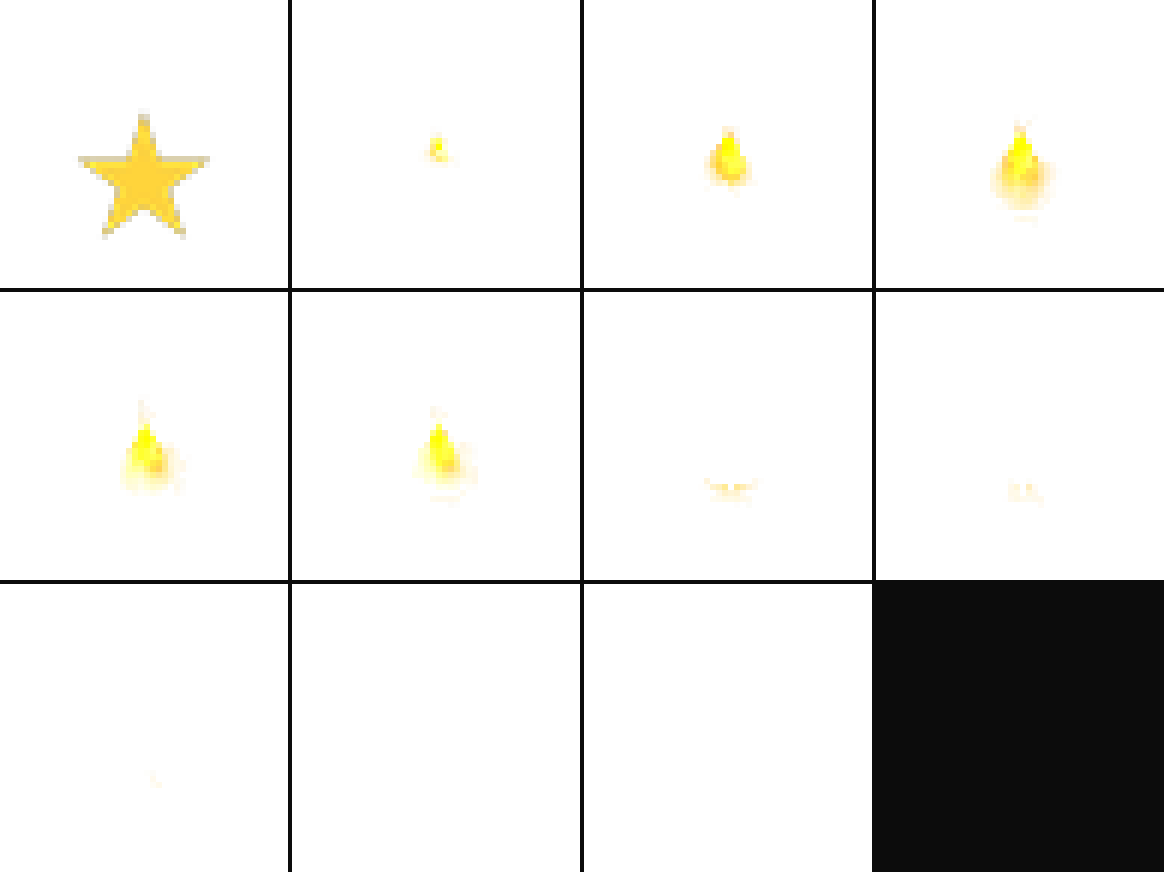


--- step 02000 ---


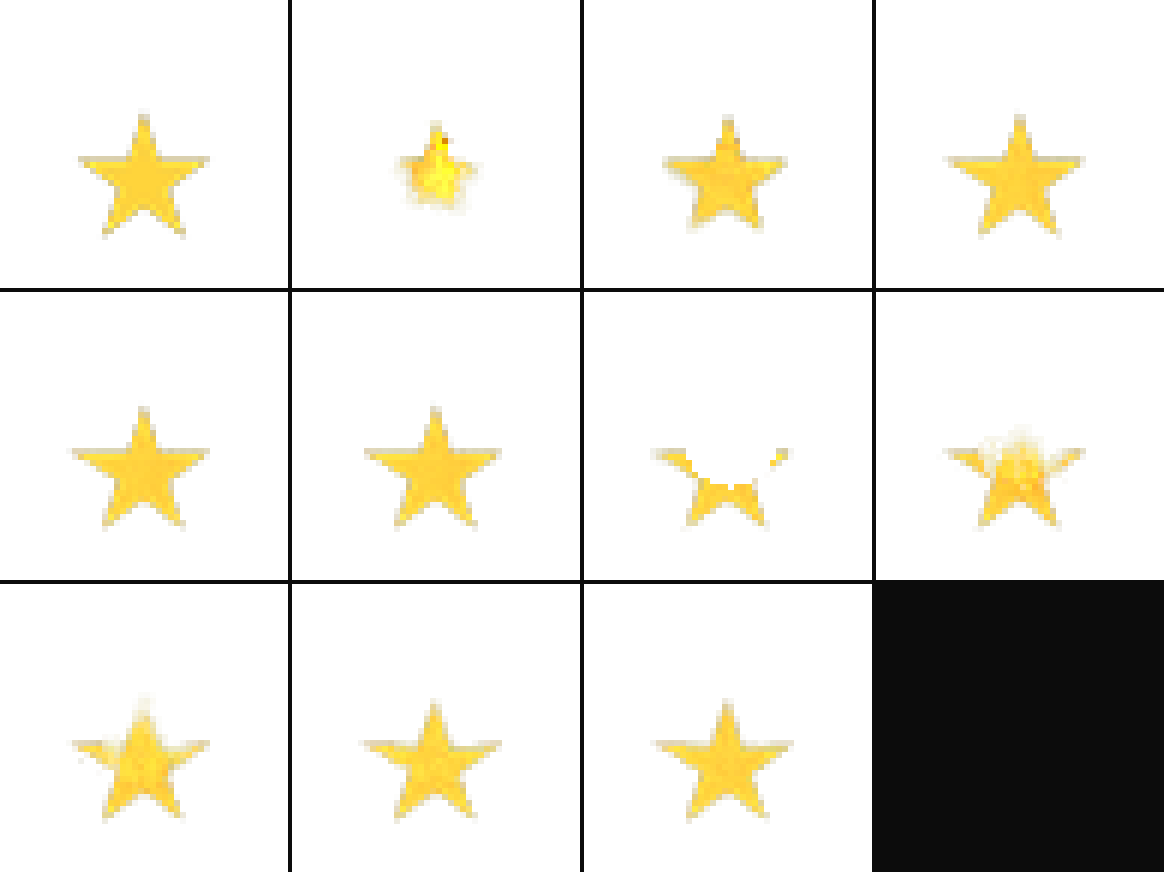


--- step 04000 ---


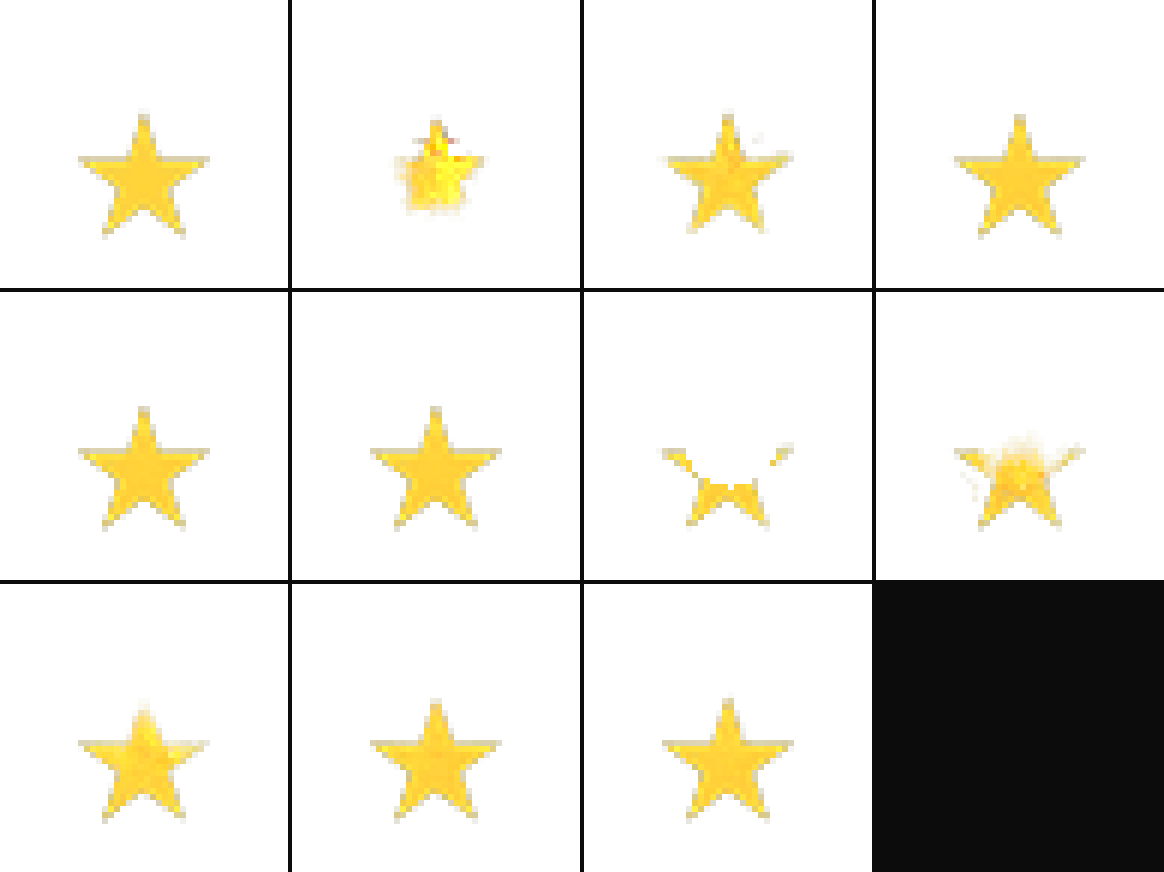


--- step 06000 ---


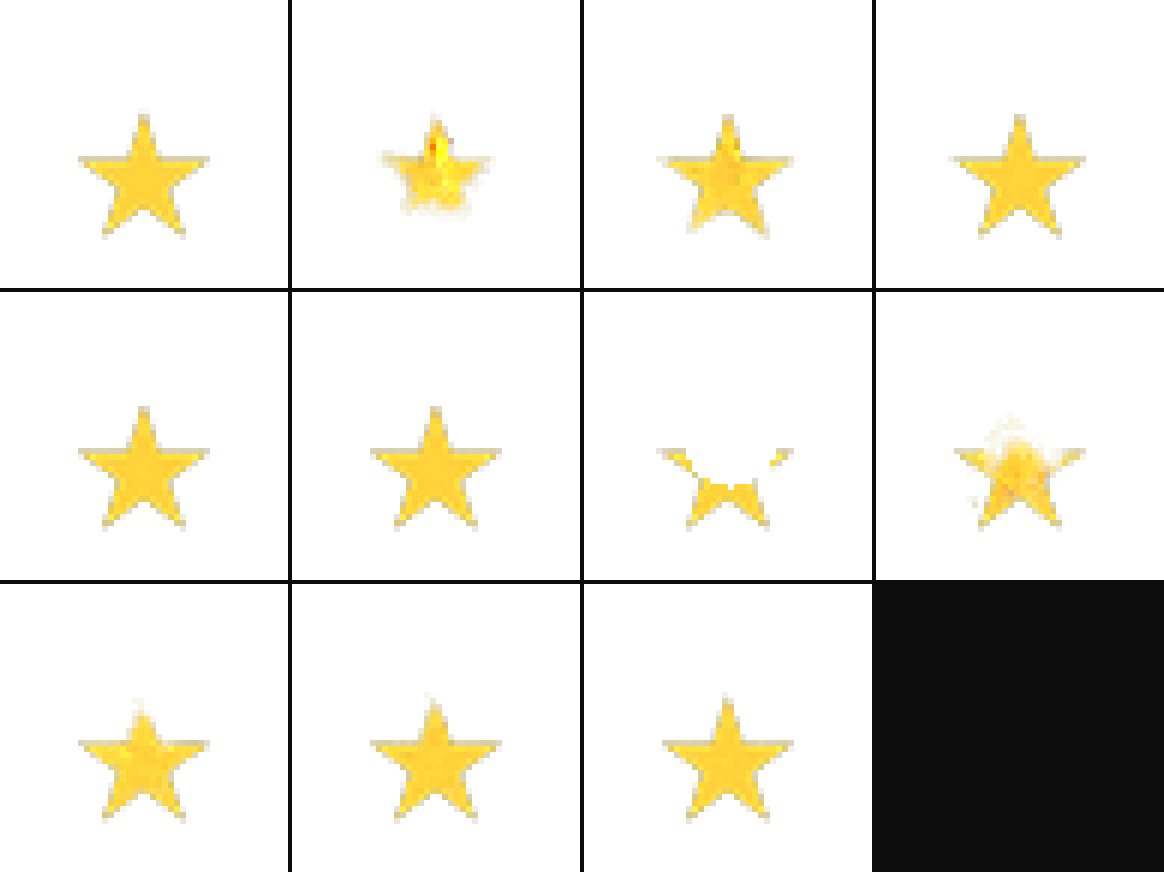


--- step 10000 ---


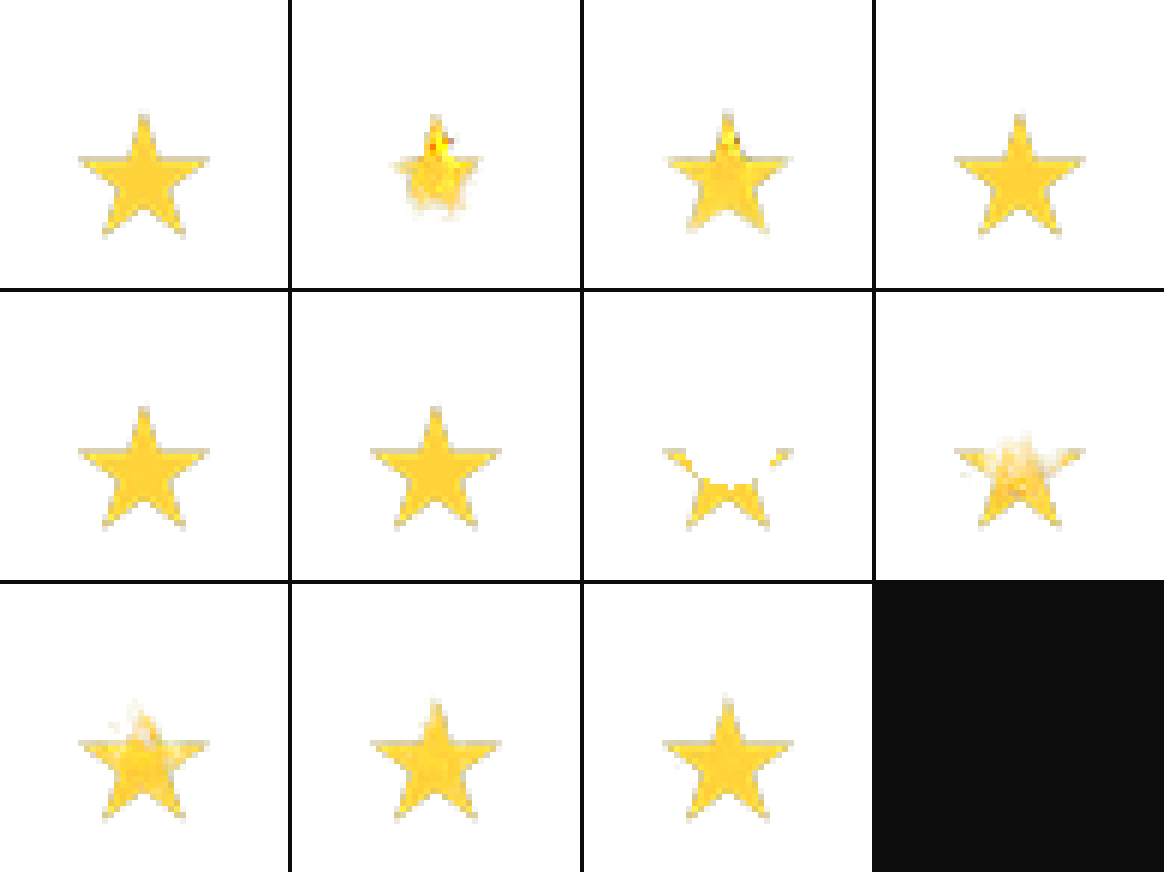

In [14]:
star_previews = sorted((V2_ROOT / "weights" / "02_star" / "seed_001" / "previews").glob("*_eval.png"))

milestones = [0, 3, 7, 11, len(star_previews) - 1]
for idx in milestones:
    if idx < len(star_previews):
        path = star_previews[idx]
        step_num = path.stem.split("_")[1]
        print(f"\n--- step {step_num} ---")
        display(IPImage(filename=str(path)))

### what a collapsed seed looks like

for contrast, let's look at the previews from star seed 0 (the collapsed one).


--- collapsed star seed 0, step 00500 ---


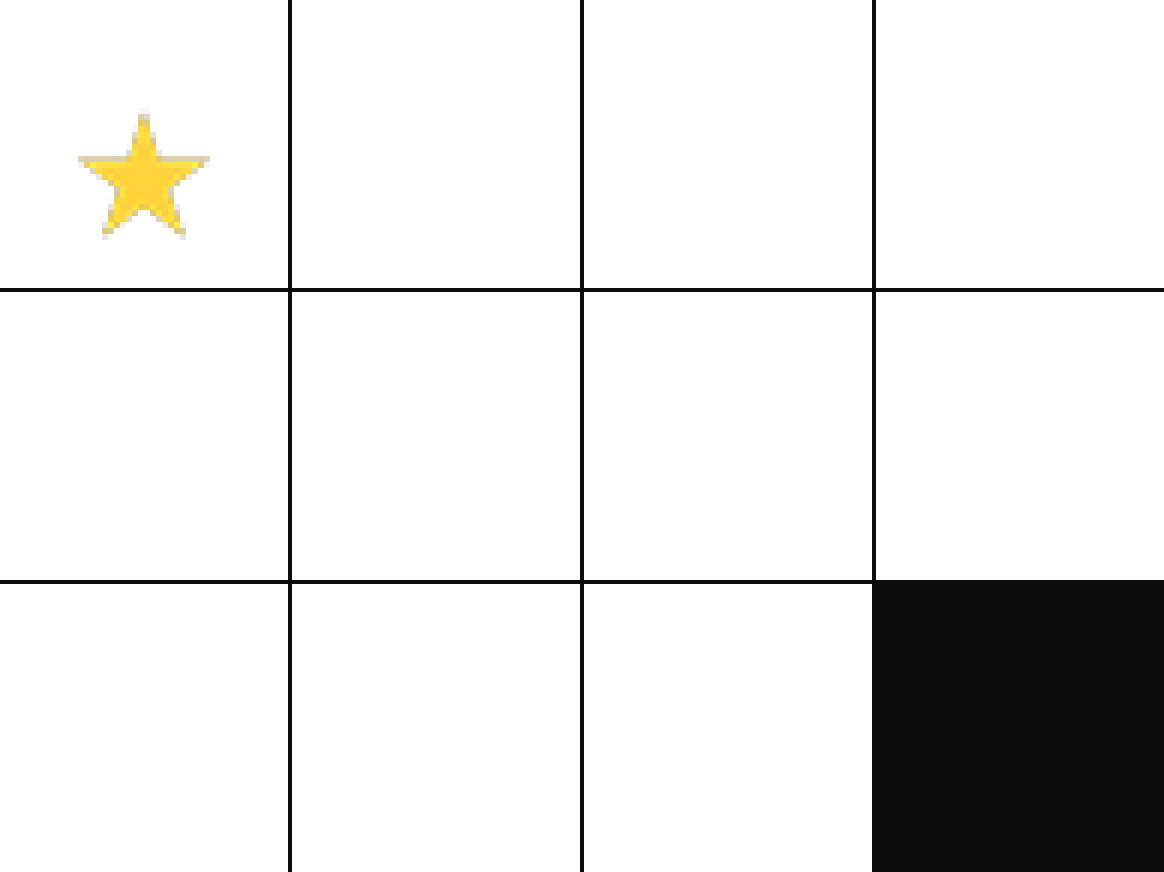


--- collapsed star seed 0, step 01000 ---


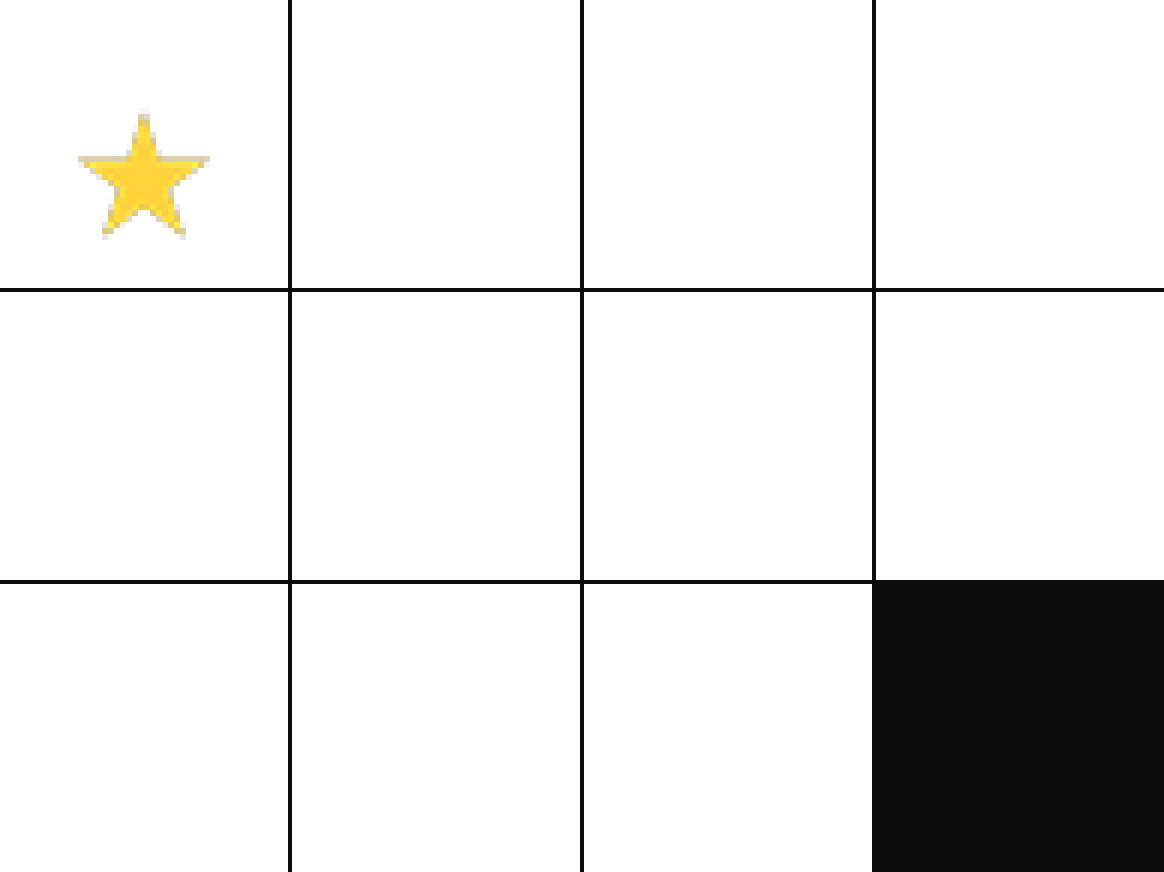


--- collapsed star seed 0, step 01500 ---


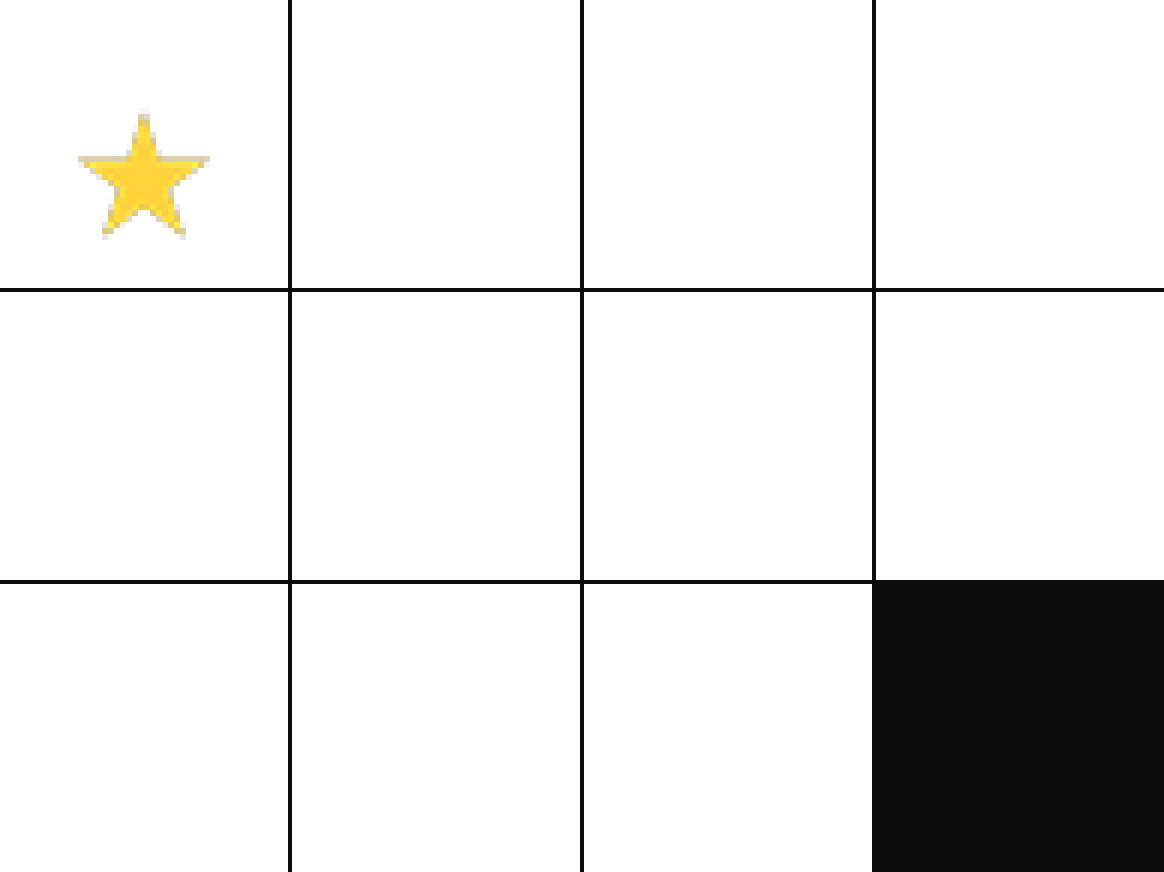


notice: the contact sheets are likely blank or show barely any structure.
this is what collapse looks like: the model produces zero output.


In [15]:
collapsed_previews = sorted((V2_ROOT / "weights" / "02_star" / "seed_000" / "previews").glob("*_eval.png"))

for path in collapsed_previews[:3]:
    step_num = path.stem.split("_")[1]
    print(f"\n--- collapsed star seed 0, step {step_num} ---")
    display(IPImage(filename=str(path)))

print("\nnotice: the contact sheets are likely blank or show barely any structure.")
print("this is what collapse looks like: the model produces zero output.")

## the real scores

let's parse the actual training metrics and see the score trajectory for each run.

In [16]:
def load_eval_history(metrics_path):
    """extract eval entries from a metrics.jsonl file."""
    rows = []
    for line in open(metrics_path):
        blob = json.loads(line)
        if blob.get("kind") == "eval":
            rows.append(blob)
    return rows

print("=== heart seed 0 (converged) ===")
heart0_evals = load_eval_history(V2_ROOT / "weights" / "01_heart" / "seed_000" / "metrics.jsonl")
for e in heart0_evals:
    marker = " <-- best" if abs(e["score"] - 5.433754813566338e-05) < 1e-10 else ""
    print(f"  step {e['step']:6d}  score {e['score']:.8f}  recovery {e['recovery_total']:.8f}{marker}")

print(f"\n=== heart seed 1 (collapsed) ===")
heart1_evals = load_eval_history(V2_ROOT / "weights" / "01_heart" / "seed_001" / "metrics.jsonl")
for e in heart1_evals[:5]:  # just show first few, they are all the same
    print(f"  step {e['step']:6d}  score {e['score']:.8f}")
print(f"  ... ({len(heart1_evals)} total evals, all identical at {heart1_evals[0]['score']:.6f})")

print(f"\n=== star seed 0 (collapsed) ===")
star0_evals = load_eval_history(V2_ROOT / "weights" / "02_star" / "seed_000" / "metrics.jsonl")
for e in star0_evals:
    print(f"  step {e['step']:6d}  score {e['score']:.8f}")

print(f"\n=== star seed 1 (converged) ===")
star1_evals = load_eval_history(V2_ROOT / "weights" / "02_star" / "seed_001" / "metrics.jsonl")
for e in star1_evals:
    marker = " <-- best" if abs(e["score"] - 4.607882792697637e-05) < 1e-10 else ""
    print(f"  step {e['step']:6d}  score {e['score']:.8f}  recovery {e['recovery_total']:.8f}{marker}")

=== heart seed 0 (converged) ===
  step    500  score 0.08634658  recovery 0.15501903
  step   1000  score 0.01088345  recovery 0.01528669
  step   1500  score 0.00716295  recovery 0.01005577
  step   2000  score 0.00361473  recovery 0.00536165
  step   2500  score 0.00080209  recovery 0.00146408
  step   3000  score 0.00088820  recovery 0.00174416
  step   3500  score 0.00088334  recovery 0.00176603
  step   4000  score 0.00030460  recovery 0.00053841
  step   4500  score 0.00007597  recovery 0.00013677
  step   5000  score 0.00007356  recovery 0.00012391
  step   5500  score 0.00063240  recovery 0.00136624
  step   6000  score 0.00009662  recovery 0.00019324
  step   6500  score 0.00015972  recovery 0.00034660
  step   7000  score 0.00011414  recovery 0.00022679
  step   7500  score 0.00007850  recovery 0.00015597
  step   8000  score 0.00847511  recovery 0.00831513
  step   8500  score 0.00007276  recovery 0.00014202
  step   9000  score 0.00006659  recovery 0.00012678
  step   9500

the contrast is stark. the collapsed seeds are stuck at their initial loss forever. the converged seeds show a clean descent curve with the score dropping by four orders of magnitude.

notice that heart seed 0's best score is at step 11000, not at the final step 12000. the last 1000 steps actually made it slightly worse. this is normal for ncas: the long rollouts late in training can push the model past its optimum. the best checkpoint system catches this.

## the best summaries in detail

the `best_summary.json` for each converged seed contains the full breakdown of every loss term at each eval step.

In [17]:
print("=== heart seed 0 best summary ===")
heart_best = json.loads((V2_ROOT / "weights" / "01_heart" / "seed_000" / "best_summary.json").read_text())
print(f"overall score: {heart_best['score']:.10f}")
print(f"best step: {heart_best['step']}")
print()
print("eval points:")
for point in heart_best["summary"]["points"]:
    print(f"  step {point['step']:4d}: total={point['total']:.8f}  rgb={point['rgb']:.8f}  alpha={point['alpha']:.8f}  overflow={point['overflow_alpha']:.1e}")
print()
rec = heart_best["summary"]["recovery"]
print(f"recovery: total={rec['total']:.8f}  rgb={rec['rgb']:.8f}  alpha={rec['alpha']:.8f}")

print()
print("=== star seed 1 best summary ===")
star_best = json.loads((V2_ROOT / "weights" / "02_star" / "seed_001" / "best_summary.json").read_text())
print(f"overall score: {star_best['score']:.10f}")
print(f"best step: {star_best['step']}")
print()
print("eval points:")
for point in star_best["summary"]["points"]:
    print(f"  step {point['step']:4d}: total={point['total']:.8f}  rgb={point['rgb']:.8f}  alpha={point['alpha']:.8f}  overflow={point['overflow_alpha']:.1e}")
print()
rec = star_best["summary"]["recovery"]
print(f"recovery: total={rec['total']:.8f}  rgb={rec['rgb']:.8f}  alpha={rec['alpha']:.8f}")

=== heart seed 0 best summary ===
overall score: 0.0000543375
best step: 11000

eval points:
  step   64: total=0.00287680  rgb=0.00067171  alpha=0.00118007  overflow=0.0e+00
  step  128: total=0.00006354  rgb=0.00001957  alpha=0.00002283  overflow=0.0e+00
  step  192: total=0.00003405  rgb=0.00001048  alpha=0.00001125  overflow=0.0e+00
  step  256: total=0.00003278  rgb=0.00000992  alpha=0.00001093  overflow=0.0e+00

recovery: total=0.00009319  rgb=0.00003264  alpha=0.00003060

=== star seed 1 best summary ===
overall score: 0.0000460788
best step: 7500

eval points:
  step   64: total=0.00555958  rgb=0.00211921  alpha=0.00166116  overflow=0.0e+00
  step  128: total=0.00004622  rgb=0.00001720  alpha=0.00001255  overflow=0.0e+00
  step  192: total=0.00003122  rgb=0.00001046  alpha=0.00000871  overflow=0.0e+00
  step  256: total=0.00003092  rgb=0.00001025  alpha=0.00000852  overflow=0.0e+00

recovery: total=0.00007395  rgb=0.00003047  alpha=0.00001799


a few things to notice:

- overflow_alpha is 0.0 for both models at their best checkpoints. the 5.0 weight on overflow did its job: the organisms learned to stay within their boundaries.
- bg_alpha is also 0.0 or near-zero. no alpha leakage into the background.
- the step-64 losses are noticeably higher than step-128 and beyond. this is because the organism is still growing at step 64. by step 128 it has usually finished forming and the remaining steps just maintain the shape.
- recovery losses are slightly worse than the best rollout losses. this is expected: healing from a crater is harder than just sitting there being a shape.

## the training speed

let's extract some speed metrics from the training logs.

In [18]:
def extract_speed_and_timing(metrics_path):
    speeds = []
    start_time = None
    end_time = None
    for line in open(metrics_path):
        blob = json.loads(line)
        if blob.get("kind") == "train" and "speed" in blob:
            speeds.append(blob["speed"])
        if blob.get("kind") == "run_start":
            start_time = blob.get("time")
        if blob.get("kind") in ("run_end", "run_stop"):
            end_time = blob.get("time")
    return speeds, start_time, end_time

h0_speeds, h0_start, h0_end = extract_speed_and_timing(V2_ROOT / "weights" / "01_heart" / "seed_000" / "metrics.jsonl")
s1_speeds, s1_start, s1_end = extract_speed_and_timing(V2_ROOT / "weights" / "02_star" / "seed_001" / "metrics.jsonl")

if h0_speeds:
    # skip first few which include warmup
    steady = h0_speeds[5:] if len(h0_speeds) > 5 else h0_speeds
    print(f"heart seed 0:")
    print(f"  steady-state speed: {sum(steady)/len(steady):.1f} it/s")
    print(f"  started: {h0_start}")
    print(f"  ended:   {h0_end}")
    print(f"  12000 steps total")

if s1_speeds:
    steady = s1_speeds[5:] if len(s1_speeds) > 5 else s1_speeds
    print(f"\nstar seed 1:")
    print(f"  steady-state speed: {sum(steady)/len(steady):.1f} it/s")
    print(f"  started: {s1_start}")
    print(f"  ended:   {s1_end}")
    print(f"  10000 steps (stopped early: converged)")

print(f"\nall runs used: cuda, amp=bfloat16, channels_last=true")
print(f"compile was set to false in the actual runs (resolved config shows this)")

heart seed 0:
  steady-state speed: 4.0 it/s
  started: 20260322-190157
  ended:   20260322-200923
  12000 steps total

star seed 1:
  steady-state speed: 4.3 it/s
  started: 20260322-211117
  ended:   20260322-220116
  10000 steps (stopped early: converged)

all runs used: cuda, amp=bfloat16, channels_last=true
compile was set to false in the actual runs (resolved config shows this)


## resume and rng restore

one of the later fixes on the v2 branch (`9b972b7` - "fix rng restore on resume") was about a subtle but important problem.

when a training run resumes from a checkpoint, it loads back the model weights, optimizer state, scaler state, learning rate scheduler state, and the pool of partial states. but if it does not also restore the random number generator state, the resumed run will not produce the same sequence of random numbers as the original would have.

this matters because:
- the rollout length is sampled randomly each step
- the pool indices are sampled randomly
- the damage craters use random positions and radii
- the stochastic fire mask is random

if you resume without rng restore, all of these values change. the run is no longer reproducible. in practice this also made some resumed runs slightly worse because the damage distribution shifted.

the fix saves the full rng state (python, numpy, torch cpu, torch cuda) into the latest checkpoint and restores it on resume.

In [19]:
# verify the rng blob is in a checkpoint
import torch

latest_path = V2_ROOT / "weights" / "01_heart" / "seed_000" / "checkpoints" / "latest.pt"
if latest_path.exists():
    blob = torch.load(latest_path, map_location="cpu", weights_only=False)
    print("latest checkpoint keys:", list(blob.keys()))
    if "rng" in blob:
        print("rng blob keys:", list(blob["rng"].keys()))
        print("torch rng state shape:", blob["rng"]["torch"].shape)
    print(f"saved at: {blob.get('saved_at', 'unknown')}")
    print(f"step: {blob.get('step', 'unknown')}")
    print(f"best_score: {blob.get('best_score', 'unknown')}")
else:
    print("no latest checkpoint found (only best.pt is shipped)")

latest checkpoint keys: ['step', 'best_score', 'model', 'optimizer', 'scaler', 'scheduler', 'pool', 'rng', 'config', 'saved_at']
rng blob keys: ['python', 'numpy', 'torch', 'cuda']
torch rng state shape: torch.Size([5056])
saved at: 20260322-200923
step: 12000
best_score: 5.433754813566338e-05


## the lr schedule

v2 uses a cosine learning rate schedule with warmup. this was another addition that v1 did not have.

In [20]:
import math

base_lr = config["train"]["lr"]
warmup_steps = config["train"]["warmup_steps"]
total_steps = config["train"]["steps"]
min_lr_scale = config["train"]["min_lr_scale"]

print(f"base lr: {base_lr}")
print(f"warmup: {warmup_steps} steps")
print(f"min lr scale: {min_lr_scale} (min lr = {base_lr * min_lr_scale})")
print()

print(f"{'step':>8s}  {'lr':>12s}  {'scale':>8s}")
print("-" * 32)
for step in [1, 50, 125, 250, 500, 1000, 3000, 6000, 9000, 12000]:
    if step < warmup_steps:
        scale = max(1, step) / warmup_steps
    else:
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        scale = min_lr_scale + (1.0 - min_lr_scale) * cosine
    print(f"{step:8d}  {base_lr * scale:12.8f}  {scale:8.4f}")

base lr: 0.0015
warmup: 250 steps
min lr scale: 0.08 (min lr = 0.00012)

    step            lr     scale
--------------------------------
       1    0.00000600    0.0040
      50    0.00030000    0.2000
     125    0.00075000    0.5000
     250    0.00150000    1.0000
     500    0.00149846    0.9990
    1000    0.00148617    0.9908
    3000    0.00132174    0.8812
    6000    0.00083306    0.5554
    9000    0.00033032    0.2202
   12000    0.00012000    0.0800


the warmup is only 250 steps, which is about 2% of the total run. the cosine decay brings the lr down to 8% of its peak by the end. this is a standard recipe that works well for small models: you want the early phase to explore aggressively and the late phase to fine-tune.

## the trainer package

the `trainer/` directory exists as a separate package because the training system needs to work in two contexts:

1. **local**: you run `python train.py --target targets/01_heart.png` from the `v2/` directory. this uses the trainer internally.
2. **remote**: you ssh into a rented gpu machine, run `bash trainer/scripts/launch_remote.sh`, and it trains all targets in the background.

the package structure is:

- `trainer/common.py` - shared utilities: file loading, config parsing, model construction, image helpers, rng checkpointing
- `trainer/train_v2.py` - the single-target trainer: loss function, eval, checkpointing, early stopping, the full training loop
- `trainer/train_all_v2.py` - the multi-target orchestrator: iterates targets and seeds, handles collapse retries
- `trainer/eval_v2.py` - standalone checkpoint evaluation
- `trainer/preflight.py` - a smoke test that runs 8 training steps to verify the environment works
- `trainer/bundle_run.py` - packs the useful outputs into a tarball for retrieval
- `trainer/configs/single_gpu_base.toml` - the default config
- `trainer/scripts/` - shell wrappers for remote use

In [21]:
# what's in the scripts directory
scripts_dir = V2_ROOT / "trainer" / "scripts"
for script in sorted(scripts_dir.glob("*.sh")):
    first_line = script.read_text().split("\n")[0]
    print(f"  {script.name:25s}  {first_line}")

  bootstrap_vast.sh          #!/usr/bin/env bash
  bundle_group.sh            #!/usr/bin/env bash
  launch_remote.sh           #!/usr/bin/env bash
  preflight.sh               #!/usr/bin/env bash
  run_all.sh                 #!/usr/bin/env bash
  status.sh                  #!/usr/bin/env bash


the remote workflow is:

1. `bootstrap_vast.sh` - creates a venv, installs torch if needed, checks cuda version, installs requirements
2. `preflight.sh` - runs 8 training steps to verify everything works before committing to a long run
3. `launch_remote.sh` - starts training in the background with nohup, logs to a timestamped file
4. `status.sh` - checks if training is still running and shows the tail of the log
5. `bundle_group.sh` - packs the useful outputs for retrieval

the bootstrap script is interesting because it creates a venv on the remote machine but does not pin a torch version. the reasoning: rented gpu machines usually come with a pytorch image pre-installed, and you want to use whatever torch build matches their cuda version. the script checks that torch >= 2.7 and cuda >= 12.6 are available.

## path fixes and the cwd problem

commits `2ad0b6c` ("fix v2 cwd handling") and `89cb84a` ("rename v2 trainer package") fixed a real problem that only shows up after the repo split.

the original v2 code assumed it was always run from the `v2/` directory. all paths like `targets/01_heart.png` and `weights/01_heart.pt` were relative to the working directory. this worked fine when the code lived at the repo root.

after the split into `v2/`, running from the repo root would break because `targets/` does not exist there. the fix was to use `Path(__file__).resolve().parent` to find the v2 root directory and resolve all paths relative to that. this is the `PROJECT_ROOT` in `trainer/common.py` and the `V2_ROOT` in `clash.py`.

## the bootstrap fix

commit `0dc6ca9` ("use v2 trainer for bootstrap") fixed the bootstrap path in `clash.py`.

the bootstrap is what happens when you run `clash.py` and there are no trained weights: it does a short training run to produce minimum viable weights. in v1, this called `train.py` directly, which saved a flat `.pt` file.

after the v2 split, the bootstrap needed to use the v2 trainer, which saves weights in the `weights/<target>/seed_<n>/checkpoints/best.pt` directory structure. the fix rewired the bootstrap to call `train.train_target()` which goes through the v2 trainer and exports to the right location.

## now: the clash game

this is where all the training work pays off. `clash.py` puts two trained organisms on the same grid and lets them fight.

the clash system evolved significantly from v1 to v2. let me explain the key changes.

## why clash originally broke

the very first attempt at clash (described in the v1 notebook) used one shared state grid. both models looked at the same 16-channel grid, proposed updates, and the owner of each cell decided which update to apply.

this was catastrophically wrong.

the problem is that the hidden channels (5 through 16) carry the model's internal state. they are its working memory. when model a writes its hidden state into a cell and then model b reads that cell in the next step, model b sees garbage. it was trained on its own hidden representations, not model a's.

the result was that both organisms would quickly dissolve at the boundary between territories. the hidden channels became toxic waste dumps and the organisms could not maintain themselves.

the fix (which v1 already had by the time of its walkthrough) was **separate hidden states**.

## separate hidden states

the current clash design maintains two full state grids:

- `state_a`: the complete state for organism a (all 24 channels)
- `state_b`: the complete state for organism b (all 24 channels)

each model proposes an update based on its own state only. neither model ever sees the other's hidden channels.

a separate `owner` grid tracks which cells belong to which organism (0 = unclaimed, 1 = organism a, 2 = organism b). after both models propose updates, the ownership logic decides what happens.

## the ownership logic: from v1 to v2

### v1 ownership (binary)

in v1, ownership was decided per-step by comparing alpha values:

- if only one model claims a cell, it gets it
- if both claim it, the one with higher alpha wins
- a support check killed isolated cells (any cell owned by a side where fewer than 2/9 neighbors also belonged to that side was killed)

this was simple but had problems:
- ownership flickered: a cell could change sides every frame
- ties silently favored the left side (model a's alpha was checked first with `>=`)
- there was no momentum or inertia; territorial gains could be instantly reversed

### v2 ownership (momentum-based)

commit `704939a` ("add momentum-based clash control") replaced the binary system with a continuous control field.

instead of an owner grid that is 0/1/2 per cell, v2 uses a floating-point `control` grid in the range [-1, +1]:

- positive values = organism a's territory
- negative values = organism b's territory
- zero = neutral

each step:
1. both models propose updates
2. the pressure at each cell is computed: `strength_a - strength_b`, where strength is the clamped alpha value in cells the organism can claim
3. a tie margin (0.01) zeroes out near-ties so neither side gets a free bias
4. the control field is updated: `control = control * decay + pressure * gain`
5. ownership is derived from control: above the capture threshold (+0.55) = owned by a, below -0.55 = owned by b, within the release threshold (+/-0.12) = neutral

this is much more stable than v1's binary system. the decay (0.97) means that abandoned cells slowly drift back to neutral. the capture threshold means you need sustained pressure to take territory, not just one lucky frame. and the gain (0.28) controls how fast pressure translates to territorial change.

In [22]:
# the v2 clash parameters
print("v2 clash control parameters:")
print(f"  pressure_gain     = 0.28   (how fast alpha difference translates to control change)")
print(f"  control_decay     = 0.97   (how fast abandoned cells drift to neutral)")
print(f"  capture_threshold = 0.55   (control must exceed this to claim ownership)")
print(f"  release_threshold = 0.12   (control within this range becomes neutral)")
print(f"  tie_margin        = 0.01   (pressure differences smaller than this are zeroed)")
print()
print("the gap between capture (0.55) and release (0.12) creates hysteresis:")
print("once you own a cell, you do not lose it until control drops below 0.12.")
print("this prevents the flickering that plagued v1.")

v2 clash control parameters:
  pressure_gain     = 0.28   (how fast alpha difference translates to control change)
  control_decay     = 0.97   (how fast abandoned cells drift to neutral)
  capture_threshold = 0.55   (control must exceed this to claim ownership)
  release_threshold = 0.12   (control within this range becomes neutral)
  tie_margin        = 0.01   (pressure differences smaller than this are zeroed)

the gap between capture (0.55) and release (0.12) creates hysteresis:
once you own a cell, you do not lose it until control drops below 0.12.
this prevents the flickering that plagued v1.


## fixed spawn positions

commit `29f20fb` ("add fixed clash spawn positions") added `--left-pos` and `--right-pos` arguments to clash.

the default behavior is still random spawn positions, but you can now pin them:

```bash
python clash.py --left-pos 12,24 --right-pos 36,24
```

this is useful for reproducible demonstrations and for testing whether specific spatial configurations produce different outcomes. the positions are clamped to 2 pixels from each edge to prevent spawning off the grid.

## team color rendering

commit `1b68c75` ("add team color render flag") added `--team-colors` mode.

by default, clash renders each organism with its actual rgba colors (the colors it learned during training). in team colors mode, organism a is rendered as red and organism b as blue, using only the alpha channel for intensity.

this is useful for clearly seeing territory boundaries. with actual colors, two similar-looking organisms can be hard to distinguish. team colors make ownership instantly obvious.

In [23]:
# the full list of clash.py cli arguments
clash_path = V2_ROOT / "clash.py"
text = clash_path.read_text()

# extract add_argument lines
import re
args = re.findall(r'parser\.add_argument\(([^)]+)\)', text)
print("clash.py arguments:")
for arg in args:
    # clean up the argument string
    parts = [p.strip().strip('"').strip("'") for p in arg.split(",")]
    name = parts[0]
    rest = ", ".join(parts[1:])
    print(f"  {name:25s}  {rest}")

clash.py arguments:
  --grid-size                type=int, default=0
  --window-size              type=int, default=960
  --fps                      type=int, default=30
  --left                     type=int, default=1
  --right                    type=int, default=2
  --left-seed                type=int
  --right-seed               type=int
  --left-pos                 type=parse_grid_pos
  --right-pos                type=parse_grid_pos
  --pressure-gain            type=float, default=DEFAULT_PRESSURE_GAIN
  --control-decay            type=float, default=DEFAULT_CONTROL_DECAY
  --capture-threshold        type=float, default=DEFAULT_CAPTURE_THRESHOLD
  --release-threshold        type=float, default=DEFAULT_RELEASE_THRESHOLD
  --tie-margin               type=float, default=DEFAULT_TIE_MARGIN
  --team-colors              action="store_true
  --bootstrap-steps          type=int, default=0
  --device                   default=pick_device(
  --headless-frames          type=int, default=0


## the target pack

v2 ships nine target images. let's look at them.

9 targets:
  01_heart             [TRAINED]
  02_star              [TRAINED]
  03_sun               [not yet trained]
  04_moon              [not yet trained]
  05_bolt              [not yet trained]
  06_flower            [not yet trained]
  07_umbrella          [not yet trained]
  08_yin               [not yet trained]
  09_skull             [not yet trained]

let's see them:

01_heart:


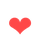


02_star:


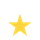


03_sun:


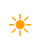


04_moon:


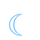


05_bolt:


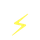


06_flower:


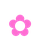


07_umbrella:


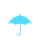


08_yin:


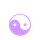


09_skull:


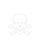

In [24]:
targets_dir = V2_ROOT / "targets"
target_files = sorted(targets_dir.glob("*.png"))

print(f"{len(target_files)} targets:")
for t in target_files:
    trained = "TRAINED" if (V2_ROOT / "weights" / t.stem).is_dir() else "not yet trained"
    print(f"  {t.stem:20s} [{trained}]")

print("\nlet's see them:")
for t in target_files:
    print(f"\n{t.stem}:")
    display(IPImage(filename=str(t)))

only heart and star have trained weights so far. the remaining seven targets have training configs but have not been run yet. this is by design: the repo ships a working demo with two organisms, and the infrastructure is ready for training the rest.

the targets are 40x40 rgba pngs. they are small and simple on purpose. the shapes need to be recognizable at the 48x48 grid scale, and overly detailed targets would be harder for the nca to maintain during long clash sessions.

## the shipped artifacts

commit `a56ec23` ("store full heart and star training artifacts") is the final commit on main. it ships the complete training output for both targets, including all seeds (both the ones that worked and the ones that collapsed).

this is a deliberate choice: keeping the collapsed seeds is useful as evidence and as test data. it shows that collapse is a real phenomenon and that the seed retry strategy is not theoretical.

In [26]:
import os

def dir_size_mb(path):
    total = 0
    for dirpath, _, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / (1024 * 1024)

print("shipped artifact sizes:")
for target_dir in sorted((V2_ROOT / "weights").iterdir()):
    if not target_dir.is_dir():
        continue
    for seed_dir in sorted(target_dir.glob("seed_*")):
        size = dir_size_mb(seed_dir)
        # count files by type
        checkpoints = list(seed_dir.glob("checkpoints/*.pt"))
        previews = list((seed_dir / "previews").glob("*.png")) if (seed_dir / "previews").exists() else []
        tb_files = list((seed_dir / "tensorboard").glob("*")) if (seed_dir / "tensorboard").exists() else []
        print(f"  {target_dir.name}/{seed_dir.name}: {size:.1f} MB "
              f"({len(checkpoints)} checkpoints, {len(previews)} previews, {len(tb_files)} tb events)")

shipped artifact sizes:
  01_heart/seed_000: 217.2 MB (2 checkpoints, 24 previews, 4 tb events)
  01_heart/seed_001: 216.7 MB (2 checkpoints, 16 previews, 1 tb events)
  02_star/seed_000: 0.2 MB (1 checkpoints, 6 previews, 1 tb events)
  02_star/seed_001: 0.8 MB (1 checkpoints, 20 previews, 1 tb events)


## the model weights: what is inside

let's load the actual best checkpoint and inspect it.

In [27]:
best_heart_path = V2_ROOT / "weights" / "01_heart" / "seed_000" / "checkpoints" / "best.pt"
best_star_path = V2_ROOT / "weights" / "02_star" / "seed_001" / "checkpoints" / "best.pt"

for name, path in [("heart (seed 0)", best_heart_path), ("star (seed 1)", best_star_path)]:
    blob = torch.load(path, map_location="cpu", weights_only=False)
    print(f"=== {name} ===")
    print(f"  checkpoint keys: {list(blob.keys())}")
    print(f"  step: {blob.get('step')}")
    print(f"  score: {blob.get('score'):.8f}")
    print(f"  saved_at: {blob.get('saved_at')}")

    model_state = blob["model"]
    total_params = sum(v.numel() for v in model_state.values())
    print(f"  model parameters: {total_params:,}")
    for key, tensor in model_state.items():
        print(f"    {key:35s} {str(tuple(tensor.shape)):20s} {tensor.dtype}")
    print()

=== heart (seed 0) ===
  checkpoint keys: ['step', 'score', 'summary', 'model', 'config', 'saved_at']
  step: 11000
  score: 0.00005434
  saved_at: 20260322-200117
  model parameters: 25,504
    perception_filters                  (72, 1, 3, 3)        torch.float32
    fc0.weight                          (256, 72, 1, 1)      torch.float32
    fc0.bias                            (256,)               torch.float32
    fc1.weight                          (24, 256, 1, 1)      torch.float32
    fc1.bias                            (24,)                torch.float32

=== star (seed 1) ===
  checkpoint keys: ['step', 'score', 'summary', 'model', 'config', 'saved_at']
  step: 7500
  score: 0.00004608
  saved_at: 20260322-214446
  model parameters: 25,504
    perception_filters                  (72, 1, 3, 3)        torch.float32
    fc0.weight                          (256, 72, 1, 1)      torch.float32
    fc0.bias                            (256,)               torch.float32
    fc1.weight     

the best checkpoint includes the model state dict, the training config, the score, and the step. it does not include the optimizer or pool state (those are in `latest.pt` for resume). this keeps the best checkpoint small.

notice the `_orig_mod.` prefix in the state dict keys if you see it. that prefix appears when the model was compiled with `torch.compile`. the `normalize_state_dict` function in `clash.py` strips it out when loading, so compiled checkpoints work seamlessly with non-compiled inference.

## the v2 clash loop in detail

let's trace through one clash step to understand exactly what happens.

In [28]:
# load both models
from nca import NCA

def load_best_model(checkpoint_path, device="cpu"):
    blob = torch.load(checkpoint_path, map_location=device, weights_only=False)
    cfg = blob["config"]["model"]
    model = NCA(channels=cfg["channels"], hidden_size=cfg["hidden_size"], fire_rate=cfg["fire_rate"]).to(device)
    # strip _orig_mod prefix if present
    state = {k.removeprefix("_orig_mod."): v for k, v in blob["model"].items()}
    model.load_state_dict(state)
    model.eval()
    return model

heart_model = load_best_model(V2_ROOT / "weights" / "01_heart" / "seed_000" / "checkpoints" / "best.pt")
star_model = load_best_model(V2_ROOT / "weights" / "02_star" / "seed_001" / "checkpoints" / "best.pt")

print(f"heart model: {sum(p.numel() for p in heart_model.parameters()):,} params")
print(f"star model:  {sum(p.numel() for p in star_model.parameters()):,} params")

heart model: 24,856 params
star model:  24,856 params


In [29]:
from nca import make_seed
import torch.nn.functional as F

size = 48
device = "cpu"

# create initial states with fixed positions
state_a = make_seed(1, channels=24, height=size, width=size, xs=[12], ys=[24], device=device)
state_b = make_seed(1, channels=24, height=size, width=size, xs=[36], ys=[24], device=device)

owner = torch.zeros(1, 1, size, size, dtype=torch.long, device=device)
owner[0, 0, 24, 12] = 1
owner[0, 0, 24, 36] = 2

control = torch.zeros(1, 1, size, size, dtype=torch.float32, device=device)
control[0, 0, 24, 12] = 1.0
control[0, 0, 24, 36] = -1.0

# run for 200 steps
with torch.inference_mode():
    for step in range(200):
        proposed_a = heart_model(state_a, steps=1)
        proposed_b = star_model(state_b, steps=1)

        alpha_a = proposed_a[:, 3:4].clamp(0, 1)
        alpha_b = proposed_b[:, 3:4].clamp(0, 1)

        owned_a = owner == 1
        owned_b = owner == 2
        near_a = F.max_pool2d(owned_a.float(), 3, stride=1, padding=1) > 0
        near_b = F.max_pool2d(owned_b.float(), 3, stride=1, padding=1) > 0

        claim_a = (alpha_a > 0.05) & (owned_a | near_a)
        claim_b = (alpha_b > 0.05) & (owned_b | near_b)

        strength_a = torch.where(claim_a, alpha_a, torch.zeros_like(alpha_a))
        strength_b = torch.where(claim_b, alpha_b, torch.zeros_like(alpha_b))
        pressure = strength_a - strength_b
        pressure = torch.where(pressure.abs() >= 0.01, pressure, torch.zeros_like(pressure))

        control = control * 0.97 + pressure * 0.28
        control = control.clamp(-1, 1)

        next_owner = owner.clone()
        next_owner = torch.where(control >= 0.55, torch.ones_like(next_owner), next_owner)
        next_owner = torch.where(control <= -0.55, torch.full_like(next_owner, 2), next_owner)
        next_owner = torch.where(control.abs() <= 0.12, torch.zeros_like(next_owner), next_owner)

        state_a = torch.where((next_owner == 1).expand_as(proposed_a), proposed_a, torch.zeros_like(proposed_a))
        state_b = torch.where((next_owner == 2).expand_as(proposed_b), proposed_b, torch.zeros_like(proposed_b))
        owner = next_owner

# count territory
cells_a = int((owner == 1).sum())
cells_b = int((owner == 2).sum())
cells_none = int((owner == 0).sum())
total = size * size

print(f"after 200 clash steps on a {size}x{size} grid:")
print(f"  heart territory: {cells_a:5d} cells ({100*cells_a/total:.1f}%)")
print(f"  star territory:  {cells_b:5d} cells ({100*cells_b/total:.1f}%)")
print(f"  unclaimed:       {cells_none:5d} cells ({100*cells_none/total:.1f}%)")

after 200 clash steps on a 48x48 grid:
  heart territory:   173 cells (7.5%)
  star territory:     66 cells (2.9%)
  unclaimed:        2065 cells (89.6%)


## comparing v1 and v2

here is a side-by-side of the key differences.

In [30]:
comparison = [
    ("model channels",      "16",                   "24"),
    ("hidden size",         "128",                  "256"),
    ("training steps",      "3000",                 "12000"),
    ("pool size",           "1024",                 "2048"),
    ("batch size",          "8",                    "48"),
    ("rollout range",       "64-96 (fixed)",        "48-96 -> 160-256 (curriculum)"),
    ("loss function",       "mse(rgba)",            "7-term weighted (rgba, rgb, alpha, bg, overflow, mass, hidden)"),
    ("eval",                "none",                 "every 500 steps, rollout + recovery"),
    ("best checkpoint",     "no",                   "yes (scored by eval)"),
    ("resume",              "basic (model only)",   "full (model, optimizer, scaler, scheduler, pool, rng)"),
    ("lr schedule",         "constant",             "cosine with warmup"),
    ("collapse detection",  "none",                 "yes (auto-stop + seed retry)"),
    ("convergence stop",    "none",                 "yes"),
    ("clash ownership",     "binary (alpha compare)", "momentum-based (control field + decay)"),
    ("clash spawn",         "random only",          "random + fixed positions"),
    ("team colors",         "no",                   "yes"),
    ("tensorboard",         "no",                   "yes"),
    ("remote training",     "no",                   "yes (shell scripts, bootstrap, preflight)"),
]

print(f"{'feature':30s} {'v1':30s} {'v2':50s}")
print("-" * 110)
for feature, v1_val, v2_val in comparison:
    print(f"{feature:30s} {v1_val:30s} {v2_val:50s}")

feature                        v1                             v2                                                
--------------------------------------------------------------------------------------------------------------
model channels                 16                             24                                                
hidden size                    128                            256                                               
training steps                 3000                           12000                                             
pool size                      1024                           2048                                              
batch size                     8                              48                                                
rollout range                  64-96 (fixed)                  48-96 -> 160-256 (curriculum)                     
loss function                  mse(rgba)                      7-term weighted (rgba, rgb, alpha, b

## what worked

1. **the rollout curriculum**. this is the single biggest improvement. v1 organisms dissolved in clash because they had only seen 96-step horizons. v2 organisms are stable for hundreds of steps because they trained at up to 256.

2. **the overflow penalty**. weighting it at 5.0 (ten times the rgba weight) was aggressive but correct. organisms now produce clean shapes without the alpha fringe that made v1 organisms look sloppy.

3. **the seed retry strategy**. half the seeds collapsed. if the trainer had just stopped at seed 0, star would have shipped with garbage weights. the fallback to seed 1 saved it.

4. **momentum-based clash control**. the hysteresis between capture (0.55) and release (0.12) eliminated the ownership flickering that made v1 clashes look noisy. territory changes are now smooth and directional.

5. **the eval pipeline with recovery scoring**. scoring models on their ability to heal from damage turned out to be a better predictor of clash performance than pure shape fidelity. a model with a slightly worse rgb loss but better recovery will outperform in clash.

6. **separate hidden states**. this was already in v1, but it is worth reiterating: this is the foundational insight that makes clash work at all. without separate state grids, two ncas cannot coexist.

## what failed

1. **compile=true in the config but compile=false in practice**. the resolved config shows that compilation was disabled for the actual runs. torch.compile can be finicky with small models and dynamic control flow (the stochastic fire mask). it might work with the right settings but was not worth debugging during the initial training runs.

2. **half the seeds collapsed**. a 50% collapse rate is high. this suggests the architecture or initialization could be improved. possible directions: different weight initialization, warmup from a pretrained seed, or architectural changes that make early training more stable.

3. **only two targets trained**. the infrastructure supports all nine targets, but only heart and star were trained to convergence. this is mostly a time constraint, not a technical one.

## what was learned

1. **nca training is stochastic and fragile**. the same config can produce scores ranging from 0.00005 to 0.88 depending on the random seed. any serious nca training system must handle this.

2. **collapse is detectable early**. collapsed runs show a flat loss from the very beginning. the collapse detector at 3000 steps could probably be moved to 1000 steps without losing anything.

3. **the overflow loss is the most important addition**. without it, organisms produce beautiful centers but leak alpha everywhere. with it, they stay bounded. the 9-pixel overflow kernel gives enough margin that the organism can have a soft edge without being penalized, but anything beyond that margin gets crushed.

4. **recovery ability correlates with clash performance**. models that score well on the damage-and-recover eval also perform well in clash, because clash is essentially continuous damage and recovery at the territorial boundary.

5. **momentum-based control was the right abstraction for territory**. trying to compute ownership per-frame from instantaneous alpha values was always going to be noisy. the control field acts as a low-pass filter on territorial intent, and the threshold hysteresis prevents oscillation.

## the training metrics in full

let's visualize the training trajectory for the two converged seeds.

In [31]:
def load_train_metrics(metrics_path):
    rows = []
    for line in open(metrics_path):
        blob = json.loads(line)
        if blob.get("kind") == "train":
            rows.append(blob)
    return rows

heart_train = load_train_metrics(V2_ROOT / "weights" / "01_heart" / "seed_000" / "metrics.jsonl")
star_train = load_train_metrics(V2_ROOT / "weights" / "02_star" / "seed_001" / "metrics.jsonl")

# show summary stats
for name, rows in [("heart seed 0", heart_train), ("star seed 1", star_train)]:
    if not rows:
        continue
    steps = [r["step"] for r in rows]
    totals = [r["total"] for r in rows]
    rollouts = [r["rollout"] for r in rows]
    speeds = [r["speed"] for r in rows if r["speed"] > 0.1]  # skip warmup outliers

    print(f"\n=== {name} ===")
    print(f"  steps: {steps[0]} to {steps[-1]} ({len(rows)} log entries)")
    print(f"  initial loss: {totals[0]:.6f}")
    print(f"  final loss:   {totals[-1]:.8f}")
    print(f"  rollout range: {min(rollouts)} to {max(rollouts)}")
    print(f"  avg speed: {sum(speeds)/len(speeds):.1f} it/s" if speeds else "  no speed data")

    # show loss at key milestones
    print(f"  \n  loss progression:")
    for target_step in [1, 100, 500, 1000, 2000, 4000, 6000, 8000, 10000, 12000]:
        closest = min(rows, key=lambda r: abs(r["step"] - target_step))
        if abs(closest["step"] - target_step) < 50:
            print(f"    step {closest['step']:6d}: loss={closest['total']:.8f}  rollout={closest['rollout']}")


=== heart seed 0 ===
  steps: 1 to 12000 (482 log entries)
  initial loss: 0.674475
  final loss:   0.00003082
  rollout range: 52 to 249
  avg speed: 4.0 it/s
  
  loss progression:
    step      1: loss=0.67447525  rollout=67
    step    100: loss=0.64156383  rollout=88
    step    500: loss=0.55123144  rollout=77
    step   1000: loss=0.24163684  rollout=62
    step   2000: loss=0.02565305  rollout=97
    step   4000: loss=0.01433279  rollout=95
    step   6000: loss=0.00004890  rollout=145
    step   8000: loss=0.00183846  rollout=156
    step  10000: loss=0.00003306  rollout=181
    step  12000: loss=0.00003082  rollout=234

=== star seed 1 ===
  steps: 1 to 10000 (401 log entries)
  initial loss: 0.884216
  final loss:   0.00003627
  rollout range: 51 to 219
  avg speed: 4.3 it/s
  
  loss progression:
    step      1: loss=0.88421649  rollout=77
    step    100: loss=0.86419153  rollout=93
    step    500: loss=0.72953498  rollout=83
    step   1000: loss=0.47130558  rollout=10

## the compiled model question

the config has `compile = true` but the resolved config for the actual runs shows `compile = false`. what happened?

when training was launched on the remote machine, compilation was likely disabled either because the bootstrap script set `--no-compile`, or because the train.py wrapper set it for the bootstrap phase and it carried through.

looking at the `train.py` bootstrap call:

```python
checkpoint_path = train_target(
    target_path,
    ...
    no_compile=True,
    ...
)
```

the bootstrap always disables compile. and the resolved config in the shipped weights confirms it was off for the full runs too. the training still worked fine at ~3 it/s without compilation. with compilation, it might have been faster, but the overhead of the initial compile pass on a 12000-step run is minimal anyway.

## how to run everything

### play a clash

```bash
cd v2
conda activate petri-clash
python clash.py
```

this uses the shipped heart (left) and star (right) weights. controls:
- `space`: pause/resume
- `r`: reset with new spawn positions  
- `1-9`: change left organism
- `shift+1-9`: change right organism
- left click: drop a damage crater
- `esc`: quit

### train a new target

```bash
cd v2
python train.py --target targets/03_sun.png --steps 12000
```

### run the full training sweep

```bash
cd v2
python -m trainer.train_all_v2 --config trainer/configs/single_gpu_base.toml
```

### evaluate a specific checkpoint

```bash
cd v2
python -m trainer.eval_v2 --run-dir runs_v2/single_gpu_all_targets/01_heart/seed_000
```

## one more thing: why the model is so small

a common reaction to the nca approach is: "wait, this model has how many parameters?"

In [32]:
model = NCA(channels=24, hidden_size=256, fire_rate=0.5)
total = sum(p.numel() for p in model.parameters())
size_kb = sum(p.numel() * p.element_size() for p in model.parameters()) / 1024

print(f"total parameters: {total:,}")
print(f"model size: {size_kb:.0f} KB")
print()
print("for comparison:")
print("  a single 256x256 rgb image is 192 KB")
print(f"  this model is {size_kb:.0f} KB")
print()
print("the model is smaller than a single moderately-sized image.")
print("and yet it encodes a local update rule that can grow, maintain,")
print("and repair a specific shape from a single pixel seed.")
print("that is the magic of neural cellular automata.")

total parameters: 24,856
model size: 97 KB

for comparison:
  a single 256x256 rgb image is 192 KB
  this model is 97 KB

the model is smaller than a single moderately-sized image.
and yet it encodes a local update rule that can grow, maintain,
and repair a specific shape from a single pixel seed.
that is the magic of neural cellular automata.


## final thought

the thing about this project that keeps surprising me is the gap between what it looks like and what it takes.

"two little pixel creatures fight on a grid" sounds like a weekend toy. but actually making it work required solving a training stability problem (curriculum + 7-term loss), an initialization problem (seed retries + collapse detection), a runtime physics problem (momentum control + hysteresis), and an infrastructure problem (resume + remote training + artifact management).

v1 proved the concept. v2 made it real. the organisms grow from a single pixel, maintain their shape over hundreds of steps, repair themselves when damaged, and hold territory against an opponent. and each one is encoded in a model that fits in 24 kilobytes.

there are still seven targets waiting to be trained.